# 08. 가설 검증 — 방향 정리 (H5~H8)

> **방향을 정리하는 노트북이다. 지금까지 코드를 실행한 곳은 2절(H5)의 그룹 만들기와 시각 확인뿐이고, 어느 가설도 검정은 하지 않았다.**
> **2026-09-22: 사용자가 가설 문장과 검정 방법을 바꿨다. 아래 내용은 바뀐 방향 기준이다.**

- 검증할 가설은 H5~H8 네 개다.
- 범위: **H5·H7·H8은 서울 전체**, **H6은 중앙대 vs 숭실대 두 학교**(통학로 구간·지점 단위)다.
- 새 방향에 있던 "Tier1 6개교" 문구는 사용하지 않기로 했다. H7은 특정 6개교로 한정하지 않고 서울 대학 전체로 진행한다.
- 입력은 `06_숭실대_반경_1-3단계.ipynb` 3단계까지 정리한 데이터(`*_clean` 프레임)와 그 처리 규칙이다.
- 06 노트북의 4~8절은 사고다발지역 탐색이었고, 뚜렷한 관계를 찾지 못했다. 그 결과는 이번 검증의 근거로 쓰지 않는다.

## 요약 — 한눈에 보기

### 가설별 방향 (2026-09-22 확정본)

| # | 범위 | 비교 | 검정 (사용자 지정) | 핵심 주의점 |
|---|---|---|---|---|
| H5 | 서울 전체 횡단보도 | 버스정류장 50m 이내/이외 두 그룹의 음향신호기 설치비율이 다르다 (양측) | 카이제곱 검정 | **보행등 유무 열 -> 사용 x**(민감도로만), 자치구 통제 필요, 교차로 단위 군집, 50m는 30·100m로 민감도 확인 |
| H6 | 중앙대 vs 숭실대 | 통학로 구간·지점별 위험도 점수 분포가 다르다 | Mann-Whitney U | 위험도 점수·통학로 정의가 아직 없음, 구간끼리 독립이 아님, 기준점 규칙 통일 필요 |
| H7 | 서울 대학 전체 | 같은 학교 안 출입문별 음향신호기 설치개수 격차 | 학교별 변동계수(CV) | 문이 1개인 학교는 CV 정의 불가, 개수는 주변 횡단보도 수에 좌우됨, "크다"의 기준값 필요 |
| H8 | 서울 전체 | 고밀도 구간에서 최근접 무음향 횡단보도까지 평균거리, 100m 이내 존재 여부 | 평균거리·존재 비율 (기술통계) | 비교 대상이 없으면 검정이 아님, "무신호·무음향" 정의 필요, 좌표 없던 신호기는 `XGEO`로 채움(2-1-1) |



### 진행 순서

횡단보도 마스터 표 → H5 → H8 → 대학·출입문 수집 → H7 → **H6은 마지막에 중앙대·숭실대만** (앞선 결과를 본 뒤) → 다중 비교 보정.

## 0. 가설 4개: 새 문장과 분석 단위

| # | 새 가설 | 검정 (사용자 지정) | 분석 단위 | 핵심 변수 |
|---|---|---|---|---|
| H5 | 버스정류장 50m 이내 횡단보도는 그 외 횡단보도보다 음향신호기 설치율이 **다를** 것이다. → 평가축: 대중교통 접근성 | 두 그룹의 음향신호기 설치비율 비교, 카이제곱 검정 | 횡단보도 (서울 전체) | 정류장 50m 이내 여부 → 음향신호기 유무 |
| H6 | 중앙대와 숭실대는 같은 동작구에 있지만, 통학로 구간 단위로 비교하면 위험도 점수 분포에 유의미한 차이가 있을 것이다. | 두 학교 통학로 내 구간/지점별 위험도 점수 분포 비교, Mann-Whitney U | 통학로 구간·지점 (두 학교) | 학교, 구간별 위험도 점수 |
| H7 | 같은 학교 안에서도 출입문마다 음향신호기 접근성 격차가 클 것이다. | 출입문별 설치개수의 변동계수(CV) 산출 | 출입문 (서울 대학 전체) | 문 주변 음향신호기 설치개수 |
| H8 | 음향신호기가 밀집한 구간에서도 무신호·무음향 횡단보도가 근접해 있어, 설비의 밀집이 곧 통학로 전체의 안전을 뜻하지는 않을 것이다. | 고밀도 구간에서 최근접 무음향 횡단보도까지 평균거리, 100m 기준 존재 여부 | 격자(또는 버퍼) (서울 전체) | 음향신호기 밀집도, 최근접 무음향 횡단보도 거리 |


## 1. H5 — 버스정류장 50m 이내 횡단보도와 음향신호기 설치율 (서울 전체)

**가설 방향, 구체화:** 버스정류장 50m안 횡단보도와 그 밖의 횡단보도의 음향신호기 설치비율이 유의미하게 다르다" 

**사용 데이터:** 서울시 버스정류소 위치정보 `서울시버스정류소위치정보(20260902).xlsx`와 그 CSV 변환본  

**가설을 통해 알고 싶은 것** : "버스정류장"이 횡단보도의 음향신호기 설치바율에 영향을 끼치는지. 
                            => 2가지 방향이 있음. (1)횡단보도의 음향신호기 비율 (2)음향신호기 자체의 비율

**문제** - 위치데이터에 대한 좌표 결측 문제. 
        => 해결 방향 : XGEO컬럼 이용 (만약 이걸 이용한다고 한다면 -> 궁극적으로 가설을 검증할 때 사고지역, 횡단보도 데이터들이랑 어떻게 좌표를 통일 할지. 다른 데이터들은 EPSG로 하는데..)



### 1-1. 음향신호기 좌표 결측 해결

**문제:** `음향신호기_현황.csv`의 좌표는 `XCE`/`YCE`(EPSG:5186)이고, 전체 21,451건 중 4,604건(21.5%)이 결측이다. 컬럼에 있는 `XGEO`는 `oracle.sql.STRUCT@...` 형태의 깨진 객체 참조 문자열이라 그대로는 쓸 수 없다(원본 shapefile의 XGEO도 마찬가지).

**해결:** 같은 원본 폴더의 `.xls` 파일(`A073_P_음향신호기_현황/.../*.xls`)에는 `XGEO`가 Oracle `SDO_POINT_TYPE(x, y, ...)` 문자열 그대로 들어 있어, 정규식으로 좌표를 뽑아낼 수 있다. `h5_master.py`의 `load_xgeo_coords()`가 이 작업을 하고 `data/h5/aud_xgeo_coords.csv`에 캐시해 둔다.

**좌표계 검증:** XCE/YCE와 XGEO가 둘 다 있는 16,847건을 비교하면 81.1%가 0.01m 이하로 같고, 96.9%가 10m 이내로 일치한다. XGEO 좌표도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 사용한다.

**적용 규칙(`load_audible`):** XCE/YCE가 있으면 그대로 쓰고, 없는 행만 XGEO로 채운다(`좌표출처 = 'XGEO복원'`). 둘 다 없으면 `좌표결측 = True`로 남긴다.

In [1]:
import sys
sys.path.insert(0, '.')
import pandas as pd

from h5_master import load_audible

audible = load_audible(use_xgeo=True)

print("전체 음향신호기 행:", len(audible))
print()
print("좌표출처별 개수:")
print(audible['좌표출처'].value_counts())
print()
n_missing = audible['좌표결측'].sum()
print(f"최종 좌표결측: {n_missing}건 ({n_missing / len(audible) * 100:.1f}%)")

전체 음향신호기 행: 21451

좌표출처별 개수:
좌표출처
XCE       16847
XGEO복원     4604
Name: count, dtype: int64

최종 좌표결측: 0건 (0.0%)


In [2]:
# XCE(원래 좌표)와 XGEO가 둘 다 있는 행에서 두 좌표가 실제로 같은 지점을 가리키는지 검증
both = audible[(audible['좌표출처'] == 'XCE') & audible['좌표차이_m'].notna()]
print(f"XCE·XGEO 둘 다 있는 행: {len(both)}건")
print()

bins = [0, 0.01, 1, 5, 10, 20, float('inf')]
labels = ['같음(0.01m 이하)', '0.01~1m', '1~5m', '5~10m', '10~20m', '20m초과']
diff_group = pd.cut(both['좌표차이_m'], bins=bins, labels=labels, include_lowest=True)
counts = diff_group.value_counts().reindex(labels)
pct = counts / len(both) * 100

for label, n, p in zip(labels, counts, pct):
    print(f"  {label:>12}: {n:>6,}건 ({p:4.1f}%)")

print()
n_10m = (both['좌표차이_m'] <= 10).sum()
print(f"10m 이내 일치: {n_10m}건 ({n_10m / len(both) * 100:.1f}%)")
print("=> XGEO도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 결측 보완에 사용한다.")

XCE·XGEO 둘 다 있는 행: 16847건

  같음(0.01m 이하): 13,656건 (81.1%)
       0.01~1m:  1,103건 ( 6.5%)
          1~5m:  1,456건 ( 8.6%)
         5~10m:    458건 ( 2.7%)
        10~20m:    131건 ( 0.8%)
         20m초과:     43건 ( 0.3%)

10m 이내 일치: 16673건 (99.0%)
=> XGEO도 XCE/YCE와 같은 좌표계(EPSG:5186)로 보고 결측 보완에 사용한다.


### 1-2. 좌표 오차가 큰 경우는 어디에 분포하는가

**문제의식:** 위 검증(1-1)은 XCE·XGEO가 둘 다 있는 16,847건끼리 비교한 것이다. 정작 XGEO로 결측을 채운 4,604건 자체는 원래 좌표가 없으니 직접 비교할 방법이 없다. "10~20m", "20m초과"처럼 차이가 큰 경우가 무작위로 흩어져 있는지, 아니면 특정 조건에 몰려 있는지부터 확인해야 4,604건을 그대로 믿어도 되는지 판단할 수 있다.

**확인 방향:**
1. `both`(둘 다 있는 16,847건)에서 시공형태(`FRM_CDE`)·설치연도별로 오차 분포를 나눠본다.
2. 20m초과 43건을 개별로 열어서 공통점(설치일자 등)이 있는지 확인한다.
3. XGEO로 채운 4,604건을 설치일자로 묶어서, 같은 날짜에 설치된 `both` 표본의 오차율을 그 배치의 "위험도"로 매핑한다(같은 날 설치된 신호기는 같은 작업/시스템 과정을 거쳤을 가능성이 높다는 가정).

**결과:**
- 시공형태 4번이 1·2번보다 오차가 뚜렷하게 크다(같음 비율 70% vs 86%/78%).
- 2007~2022년 설치분은 평균 오차 0.2~0.8m인데, **2023~2025년 설치분은 2.6~3.8m로 3배 이상** 크다.
- 20m초과 43건 중 상당수가 특정 날짜에 몰려 있다. 특히 **2023-12-11(6건 중 6건, 100%)**, **2024-12-31(4건 중 4건, 100%)**은 그날 설치된 신호기 전부가 20m 넘게 틀렸다 — 개별 신호기 문제가 아니라 그 배치의 입력 과정 문제로 보인다.
- 이 두 날짜의 패턴을 XGEO복원 4,604건에 적용하면: **고위험 24건**(대부분 이 두 날짜 설치분), 중위험 196건, 저위험 1,344건, 그리고 **판단 불가 3,040건(66%)** — 같은 날짜에 비교할 `both` 표본이 아예 없거나 너무 적어서 위험도 자체를 알 수 없다.

**결론:** 4,604건을 "XGEO니까 다 같은 신뢰도"로 취급하면 안 되고, 그중 66%는 정직하게 "모른다" 상태로 남겨야 한다. 자치구 경계 shapefile이 없어 지역별 분포는 아직 확인하지 못했다.

In [3]:
# both(XCE·XGEO 둘 다 있는 16,847건)에서 시공형태·설치연도별 오차 분포
both = audible[(audible['좌표출처'] == 'XCE') & audible['좌표차이_m'].notna()].copy()
diff_group = pd.cut(both['좌표차이_m'], bins=bins, labels=labels, include_lowest=True)
both['차이그룹'] = diff_group

print("=== 시공형태(FRM_CDE)별 차이그룹 비율(%) ===")
ct = pd.crosstab(both['FRM_CDE'], both['차이그룹'], normalize='index') * 100
ct['건수'] = both['FRM_CDE'].value_counts()
print(ct.round(1))
print()

both['설치연도'] = (both['ESB_YMD'] // 10000).astype('Int64')
print("=== 설치연도별 평균 오차(m) ===")
print(both.groupby('설치연도', observed=True)['좌표차이_m'].agg(['count', 'mean', 'median']).round(2))

=== 시공형태(FRM_CDE)별 차이그룹 비율(%) ===
차이그룹     같음(0.01m 이하)  0.01~1m  1~5m  5~10m  10~20m  20m초과    건수
FRM_CDE                                                         
1.0              86.0      3.5   7.3    2.2     0.6    0.4  7527
2.0              78.4      9.7   9.4    1.9     0.4    0.1  7407
4.0              70.4      6.7  11.5    8.2     3.0    0.3  1788
5.0              84.4      0.0  12.5    3.1     0.0    0.0    32
6.0              92.9      2.4   2.4    2.4     0.0    0.0    42

=== 설치연도별 평균 오차(m) ===
      count  mean  median
설치연도                     
2000    506  0.53    0.00
2001     16  1.36    0.00
2002      3  0.00    0.00
2003     21  0.36    0.00
2004      4  4.15    0.48
2005     17  0.26    0.00
2006     15  0.20    0.00
2007    867  0.56    0.00
2008    284  0.27    0.00
2009    449  0.63    0.00
2010    392  0.59    0.00
2011    562  0.36    0.00
2012    744  0.39    0.00
2013    735  0.38    0.00
2014    878  0.64    0.00
2015    926  0.55    0.00
2016   1207  0.68  

In [4]:
# 20m초과 43건이 특정 설치일자(배치)에 몰려 있는지 확인
big = both[both['차이그룹'] == '20m초과']
print(f"20m초과: {len(big)}건")
print()

print("설치일자별 20m초과 건수(2건 이상인 날짜만):")
vc = big['ESB_YMD'].value_counts()
print(vc[vc >= 2])
print()

print("그 날짜에 설치된 전체(both) 대비 20m초과 비율:")
for ymd in vc[vc >= 2].index:
    same_day = both[both['ESB_YMD'] == ymd]
    n_big = (same_day['차이그룹'] == '20m초과').sum()
    print(f"  {int(ymd)}: 그날 설치 {len(same_day)}건 중 20m초과 {n_big}건 ({n_big / len(same_day) * 100:.0f}%)")

20m초과: 43건

설치일자별 20m초과 건수(2건 이상인 날짜만):
ESB_YMD
20231211.0    6
20240118.0    4
20241231.0    4
20150904.0    2
20070601.0    2
20210415.0    2
20221122.0    2
20140802.0    2
Name: count, dtype: int64

그 날짜에 설치된 전체(both) 대비 20m초과 비율:
  20231211: 그날 설치 6건 중 20m초과 6건 (100%)
  20240118: 그날 설치 19건 중 20m초과 4건 (21%)
  20241231: 그날 설치 4건 중 20m초과 4건 (100%)
  20150904: 그날 설치 4건 중 20m초과 2건 (50%)
  20070601: 그날 설치 812건 중 20m초과 2건 (0%)
  20210415: 그날 설치 46건 중 20m초과 2건 (4%)
  20221122: 그날 설치 15건 중 20m초과 2건 (13%)
  20140802: 그날 설치 2건 중 20m초과 2건 (100%)


In [5]:
# XGEO로 채운 4,604건을 설치일자로 묶어, 같은 날짜 both 표본의 오차율을 위험도로 매핑
filled = audible[audible['좌표출처'] == 'XGEO복원'].copy()

day_stats = both.groupby('ESB_YMD').agg(
    both_건수=('좌표차이_m', 'size'),
    평균오차=('좌표차이_m', 'mean'),
    비율_20m초과=('좌표차이_m', lambda s: (s > 20).mean() * 100),
    비율_10m초과=('좌표차이_m', lambda s: (s > 10).mean() * 100),
).reset_index()

filled = filled.merge(day_stats, on='ESB_YMD', how='left')

print(f"XGEO복원 전체: {len(filled)}건")
print(f"  같은 날짜에 both 표본이 전혀 없는 건: {filled['both_건수'].isna().sum()}건")
print()

reliable = filled[filled['both_건수'] >= 3]
risky = reliable[reliable['비율_20m초과'] >= 30]
mid = reliable[(reliable['비율_10m초과'] >= 20) & (reliable['비율_20m초과'] < 30)]
safe = reliable[reliable['비율_10m초과'] < 20]
unknown = len(filled) - len(reliable)

print("위험도 매핑 결과 (같은 날짜 both>=3건인 경우만 판단):")
print(f"  고위험(20m초과 비율>=30%): {len(risky)}건")
print(f"  중위험(10m초과 비율 20~30%): {len(mid)}건")
print(f"  저위험(10m초과 비율<20%): {len(safe)}건")
print(f"  판단불가(같은 날짜 both 표본 <3건 또는 없음): {unknown}건 ({unknown / len(filled) * 100:.0f}%)")
print()
print("고위험 24건의 설치일자 분포:")
print(risky['ESB_YMD'].value_counts())

XGEO복원 전체: 4604건
  같은 날짜에 both 표본이 전혀 없는 건: 2210건

위험도 매핑 결과 (같은 날짜 both>=3건인 경우만 판단):
  고위험(20m초과 비율>=30%): 24건
  중위험(10m초과 비율 20~30%): 196건
  저위험(10m초과 비율<20%): 1344건
  판단불가(같은 날짜 both 표본 <3건 또는 없음): 3040건 (66%)

고위험 24건의 설치일자 분포:
ESB_YMD
20231211.0    18
20241231.0     6
Name: count, dtype: int64


## 2. 횡단보도 마스터 표

여기서부터는 위에서 검증한 `load_audible(use_xgeo=True)`의 좌표 보완 결과(XCE·YCE 우선, 결측만 XGEO로 채움)를 최종 데이터로 쓴다. `h5_master.py`의 `build_master()`가 다음을 한 번에 만든다.

- **횡단보도 1행 = 1개**(21,776행). 좌표는 정상 21,771 / 위치이상 4 / 결측 1이고, 좌표가 정상인 행만 아래 계산에 쓴다.
- **버스정류소**: 각 횡단보도에서 가장 가까운 정류소까지 거리, `정류장근처_50m`(그리고 민감도용 30m·100m) 플래그.
- **음향신호기**: 두 가지 규칙으로 매칭한다.
  - *단순 규칙*: 횡단보도에서 가장 가까운 신호기까지 거리.
  - *배정 규칙*: 신호기 하나를 가장 가까운 횡단보도 한 곳에만 배정(중복 카운트 방지). 기본 기준은 15m, 10·20·30m는 민감도용.

In [6]:
from h5_master import build_master

master, audible_final, bus = build_master(use_xgeo=True)
print("마스터 표 shape:", master.shape)
print()
print("좌표상태:")
print(master['좌표상태'].value_counts())
print()

ok = master[master['좌표상태'] == '정상'].copy()
print(f"분석 대상(좌표 정상): {len(ok)}건")
print()
print("정류장근처_50m 분포:")
print(ok['정류장근처_50m'].value_counts())
print()
print("음향_배정_15m 분포:")
print(ok['음향_배정_15m'].value_counts())

마스터 표 shape: (21776, 31)

좌표상태:
좌표상태
정상      21771
위치이상        4
결측          1
Name: count, dtype: int64

분석 대상(좌표 정상): 21771건

정류장근처_50m 분포:
정류장근처_50m
0.0    12055
1.0     9716
Name: count, dtype: int64

음향_배정_15m 분포:
음향_배정_15m
1.0    11120
0.0    10651
Name: count, dtype: int64


## 3. H5 검정 — 카이제곱

**가설:** 버스정류장 50m 이내 횡단보도와 그 밖의 횡단보도는 음향신호기 설치비율이 다르다(양측).

**그룹:** `정류장근처_50m`(0=50m 밖, 1=50m 이내) × `음향_배정_15m`(0=음향없음, 1=음향있음). 좌표가 정상인 횡단보도만 쓴다.

**검정:** `scipy.stats.chi2_contingency`로 2×2 분할표 카이제곱 검정. 효과크기는 Cramér's V로 같이 본다(카이제곱은 표본이 크면 작은 차이도 유의하게 나오기 쉽다).

In [7]:
import numpy as np
from scipy.stats import chi2_contingency

ct = pd.crosstab(ok['정류장근처_50m'], ok['음향_배정_15m'])
ct.index = ['50m밖', '50m이내']
ct.columns = ['음향없음', '음향있음']
print("분할표:")
print(ct)
print()

chi2, p, dof, exp = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"n={n}, chi2={chi2:.2f}, dof={dof}, p={p:.2e}")
print(f"Cramer's V={cramers_v:.4f}")
print()

rate = ok.groupby('정류장근처_50m')['음향_배정_15m'].mean() * 100
print("그룹별 음향신호기 설치비율(%):")
print(f"  50m밖 : {rate[0.0]:.1f}%")
print(f"  50m이내: {rate[1.0]:.1f}%")
print(f"  차이   : {rate[1.0] - rate[0.0]:+.1f}%p")

분할표:
       음향없음  음향있음
50m밖   6053  6002
50m이내  4598  5118

n=21771, chi2=17.84, dof=1, p=2.41e-05
Cramer's V=0.0286

그룹별 음향신호기 설치비율(%):
  50m밖 : 49.8%
  50m이내: 52.7%
  차이   : +2.9%p


### 3-1. 1차 결과 해석

- p < 0.001로 통계적으로 유의하다. 하지만 **Cramér's V ≈ 0.03으로 효과크기는 거의 없다고 봐야 하는 수준**이다. 설치비율도 50m밖 49.8% vs 50m이내 52.7%로 차이가 3%p 남짓이다.
- 표본이 21,771건으로 크기 때문에, 실질적으로 작은 차이도 p값은 쉽게 유의하게 나온다. **"유의하다"와 "의미 있게 다르다"를 같은 것으로 읽으면 안 된다.**
- 요약표(§요약)에 적어둔 주의점 중 아직 반영 안 한 것:
  - 보행등 유무 열은 쓰지 않기로 했다(민감도 확인에서만 참고).
  - **자치구 통제 필요** — 자치구별로 버스정류장 밀도와 음향신호기 설치율이 둘 다 다를 수 있어서, 지금 결과가 자치구 차이를 대중교통 접근성 효과로 잘못 읽은 것일 수 있다.
  - **교차로 단위 군집** — 같은 교차로의 횡단보도 여러 개가 서로 독립이 아니므로, 표준 카이제곱의 유의성이 과대평가됐을 수 있다.
  - 50m는 30m·100m로, 15m 배정 기준은 10·20·30m로 민감도를 확인해야 한다.

다음 단계는 이 네 가지 중 하나를 골라 반영하는 것이다.

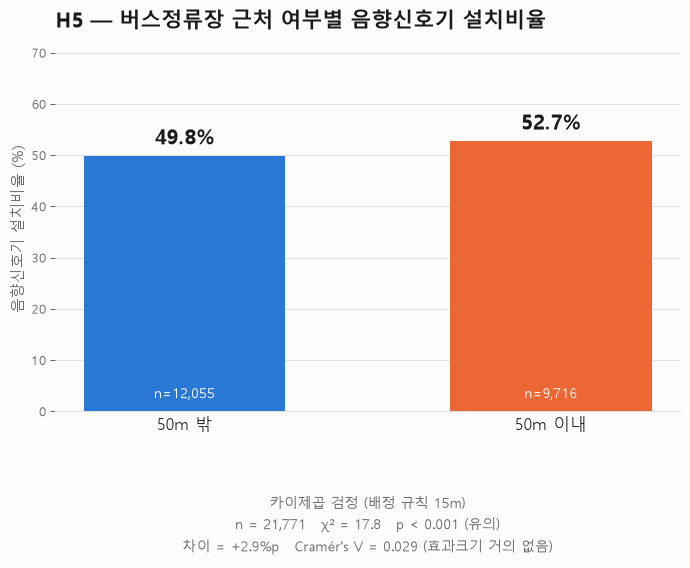

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BG, BLUE, ORANGE, INK, MUTED, GRID = '#fcfcfb', '#2A78D6', '#EB6834', '#1a1a1a', '#6b6b6b', '#e3e3e0'

counts = ok.groupby('정류장근처_50m').size()
groups = ['50m 밖', '50m 이내']
values = [rate[0.0], rate[1.0]]
ns = [counts[0.0], counts[1.0]]

fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(2)
ax.bar(x, values, width=0.55, color=[BLUE, ORANGE], zorder=3)

for i, (v, cnt) in enumerate(zip(values, ns)):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold', color=INK)
    ax.text(i, 2, f'n={cnt:,}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=12, color=INK)
ax.set_ylabel('음향신호기 설치비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(values) * 1.35)
ax.set_title('H5 — 버스정류장 근처 여부별 음향신호기 설치비율',
             fontsize=15, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

sig = 'p < 0.001 (유의)' if p < 0.001 else f'p = {p:.3f}'
stat_text = (
    f"카이제곱 검정 (배정 규칙 15m)\n"
    f"n = {n:,}   χ² = {chi2:.1f}   {sig}\n"
    f"차이 = {values[1] - values[0]:+.1f}%p   Cramér's V = {cramers_v:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.22, stat_text, transform=ax.transAxes, ha='center', va='top',
         fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/08_H5_카이제곱_결과.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 4. H5 — 음향신호기 자체의 비율 (관점 전환)

§3은 **횡단보도** 단위로 "그 횡단보도에 신호기가 있는가"를 봤다. 여기서는 §1의 두 번째 방향대로 **음향신호기** 단위로 관점을 바꾼다.

**지표:** 전체 음향신호기 중 몇 %가 "버스정류장 50m 이내 횡단보도"에 배정되어 있는가. 배정 규칙은 §2와 같다(신호기 하나를 가장 가까운 횡단보도 하나에만, 15m 이내일 때만 배정).

**비교 기준(기댓값):** 만약 신호기 배치가 횡단보도 위치와 무관하게 무작위라면, 신호기도 "전체 횡단보도 중 50m 이내 그룹 비율"(44.6%)과 같은 비율로 나뉠 것이다. 이 기댓값 대비 실제 신호기 분포가 쏠려 있는지를 **카이제곱 적합도 검정**(goodness-of-fit)으로 본다. 효과크기는 비율 차이에 쓰는 Cohen's h로 잰다.

**이 검정이 정확히 무엇을 비교하는가:** "배정된 신호기 중 50m안 개수 vs 50m밖 개수"를 그냥 비교하는 게 아니다. 이 둘은 합이 100%로 정해져 있어서 항상 서로 다르게 나오고, 그 자체로는 의미 있는 비교가 안 된다.

대신 **신호기의 50m안/밖 비율이, 전체 횡단보도의 50m안/밖 비율(기준선)과 다른지**를 본다.

- 귀무가설: 신호기 비율 = 횡단보도 비율 → 신호기는 정류장 근접성과 무관하게, 횡단보도가 있는 만큼만 딸려서 설치돼 있다.
- 대립가설: 신호기 비율 ≠ 횡단보도 비율 → 신호기가 정류장 근처에 더(또는 덜) 쏠려 있다.

즉 "안 vs 밖"이 아니라 "**신호기 분포 vs 횡단보도 분포**"를 비교하는 검정이다.

In [9]:
from scipy.spatial import cKDTree

ok = ok.reset_index(drop=True)
cxy = ok[['x', 'y']].to_numpy()

aa = audible_final[~audible_final['좌표결측']].copy().reset_index(drop=True)
axy = aa[['x', 'y']].to_numpy()

tree = cKDTree(cxy)
dist, idx = tree.query(axy)  # 각 신호기의 최근접 횡단보도 거리·인덱스

aa['최근접횡단보도_m'] = dist
aa['배정됨_15m'] = dist <= 15

print(f"전체 신호기: {len(aa):,}건")
print(f"15m 이내 배정된 신호기: {aa['배정됨_15m'].sum():,}건 ({aa['배정됨_15m'].mean()*100:.1f}%)")
print(f"어느 횡단보도에도 15m 이내로 배정 안 됨: {(~aa['배정됨_15m']).sum():,}건")

assigned = aa[aa['배정됨_15m']].copy()
assigned['정류장근처_50m'] = ok['정류장근처_50m'].to_numpy()[idx[aa['배정됨_15m'].to_numpy()]]

obs = assigned['정류장근처_50m'].value_counts().sort_index()
print()
print("배정된 신호기의 그룹별 분포(관측):")
print(obs)

전체 신호기: 21,451건
15m 이내 배정된 신호기: 19,786건 (92.2%)
어느 횡단보도에도 15m 이내로 배정 안 됨: 1,665건

배정된 신호기의 그룹별 분포(관측):
정류장근처_50m
0.0    10821
1.0     8965
Name: count, dtype: int64


In [10]:
from scipy.stats import chisquare

exp_p = ok['정류장근처_50m'].value_counts(normalize=True).sort_index()  # 기대비율: 전체 횡단보도 그룹 비율
n_assigned = obs.sum()
exp_counts = exp_p.to_numpy() * n_assigned

chi2_g, p_g = chisquare(f_obs=obs.to_numpy(), f_exp=exp_counts)

obs_ratio = obs[1.0] / n_assigned
exp_ratio = exp_p[1.0]
h = 2 * np.arcsin(np.sqrt(obs_ratio)) - 2 * np.arcsin(np.sqrt(exp_ratio))

print(f"n(배정된 신호기) = {n_assigned:,}")
print(f"관측: 50m밖 {obs[0.0]:,} / 50m이내 {obs[1.0]:,}")
print(f"기대: 50m밖 {exp_counts[0]:,.0f} / 50m이내 {exp_counts[1]:,.0f}  (횡단보도 기준 비율 {exp_ratio*100:.1f}%)")
print()
print(f"chi2 = {chi2_g:.3f}, p = {p_g:.4f}")
print(f"관측 비율(50m이내) = {obs_ratio*100:.2f}%   기대 비율 = {exp_ratio*100:.2f}%   차이 = {(obs_ratio-exp_ratio)*100:+.2f}%p")
print(f"Cohen's h = {h:.4f} (효과크기 거의 없음)")

n(배정된 신호기) = 19,786
관측: 50m밖 10,821 / 50m이내 8,965
기대: 50m밖 10,956 / 50m이내 8,830  (횡단보도 기준 비율 44.6%)

chi2 = 3.720, p = 0.0538
관측 비율(50m이내) = 45.31%   기대 비율 = 44.63%   차이 = +0.68%p
Cohen's h = 0.0137 (효과크기 거의 없음)


### 4-1. 결과 해석

- p ≈ 0.054로 **0.05 기준 유의하지 않다**(경계선). 관측 비율 45.3% vs 기대 비율 44.6%, 차이는 +0.7%p뿐이다.
- Cohen's h ≈ 0.014로 효과크기는 §3(Cramér's V ≈ 0.03)보다도 더 작다.
- §3(횡단보도 단위, p<0.001, 유의)과 §4(신호기 단위, p≈0.054, 비유의)가 서로 다른 결론처럼 보이지만 모순은 아니다. 서로 다른 모집단·검정을 쓴 결과다:
  - §3은 **횡단보도**가 표본(n=21,771)이고 "신호기 있음/없음"을 본다 — 신호기가 없는 횡단보도도 표본에 들어간다.
  - §4는 **배정된 신호기**가 표본(n=19,786)이고, 신호기가 전혀 없는 횡단보도는 애초에 표본에 없다. "이미 설치된 신호기가 정류장 근처에 더 쏠려 있는가"만 본다.
  - 92.2%의 신호기가 15m 이내 어떤 횡단보도에 배정되는 반면, §3에서 신호기 있는 횡단보도 비율은 51.1%(11,120/21,771)다. 즉 신호기 1개가 여러 횡단보도 후보 중 하나에만 배정되므로, 두 지표는 같은 데이터를 다른 각도로 자른 것이지 같은 검정이 아니다.
- **정리:** 두 관점 모두에서 실질적 효과크기는 작다(Cramér's V 0.03, Cohen's h 0.01 수준). "설치 여부"로 보면 통계적 유의성은 있지만 미미하고, "이미 설치된 신호기의 위치 쏠림"으로 보면 그마저도 유의하지 않다.

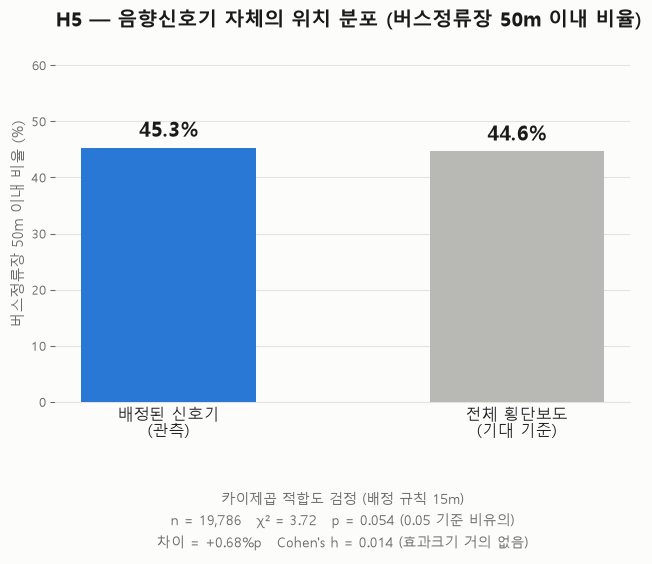

In [11]:
GRAY = '#B8B8B4'

labels = ['배정된 신호기\n(관측)', '전체 횡단보도\n(기대 기준)']
values = [obs_ratio * 100, exp_ratio * 100]
colors = [BLUE, GRAY]

fig, ax = plt.subplots(figsize=(6.5, 6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(2)
ax.bar(x, values, width=0.5, color=colors, zorder=3)

for i, v in enumerate(values):
    ax.text(i, v + 1.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold', color=INK)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11.5, color=INK)
ax.set_ylabel('버스정류장 50m 이내 비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(values) * 1.4)
ax.set_title('H5 — 음향신호기 자체의 위치 분포 (버스정류장 50m 이내 비율)',
             fontsize=14.5, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

sig = f'p = {p_g:.3f} (0.05 기준 비유의)'
stat_text = (
    f"카이제곱 적합도 검정 (배정 규칙 15m)\n"
    f"n = {n_assigned:,}   χ² = {chi2_g:.2f}   {sig}\n"
    f"차이 = {(obs_ratio - exp_ratio) * 100:+.2f}%p   Cohen's h = {h:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.24, stat_text, transform=ax.transAxes, ha='center', va='top',
         fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/09_H5_신호기비율_결과.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 5. 민감도 확인 — 정류장 기준 30m

§요약표의 주의점대로, 버스정류장 근접 기준을 50m에서 30m로 바꿨을 때 §3(횡단보도 단위)·§4(신호기 단위) 결과가 얼마나 흔들리는지 본다. 마스터 표에 이미 `정류장근처_30m` 컬럼이 있어(§2, `build_master`의 `BUS_GROUP_M=(30,50,100)`), 같은 코드를 그룹 컬럼만 바꿔 반복한다.

In [12]:
# §3 대응: 30m 기준, 횡단보도 단위 카이제곱
ct30 = pd.crosstab(ok['정류장근처_30m'], ok['음향_배정_15m'])
ct30.index = ['30m밖', '30m이내']
ct30.columns = ['음향없음', '음향있음']
print("분할표:")
print(ct30)
print()

chi2_30, p_30, dof_30, exp_30 = chi2_contingency(ct30)
n_30 = ct30.sum().sum()
cramers_v_30 = np.sqrt(chi2_30 / (n_30 * (min(ct30.shape) - 1)))

rate_30 = ok.groupby('정류장근처_30m')['음향_배정_15m'].mean() * 100
print(f"n={n_30}, chi2={chi2_30:.2f}, p={p_30:.2e}, Cramer's V={cramers_v_30:.4f}")
print(f"30m밖 : {rate_30[0.0]:.1f}%")
print(f"30m이내: {rate_30[1.0]:.1f}%")
print(f"차이   : {rate_30[1.0] - rate_30[0.0]:+.1f}%p")

분할표:
       음향없음  음향있음
30m밖   8188  8680
30m이내  2463  2440

n=21771, chi2=4.29, p=3.83e-02, Cramer's V=0.0140
30m밖 : 51.5%
30m이내: 49.8%
차이   : -1.7%p


In [13]:
# §4 대응: 30m 기준, 신호기 단위 적합도검정
assigned['정류장근처_30m'] = ok['정류장근처_30m'].to_numpy()[idx[aa['배정됨_15m'].to_numpy()]]

obs_30 = assigned['정류장근처_30m'].value_counts().sort_index()
exp_p_30 = ok['정류장근처_30m'].value_counts(normalize=True).sort_index()
exp_counts_30 = exp_p_30.to_numpy() * n_assigned

chi2_g30, p_g30 = chisquare(f_obs=obs_30.to_numpy(), f_exp=exp_counts_30)

obs_ratio_30 = obs_30[1.0] / n_assigned
exp_ratio_30 = exp_p_30[1.0]
h_30 = 2 * np.arcsin(np.sqrt(obs_ratio_30)) - 2 * np.arcsin(np.sqrt(exp_ratio_30))

print(f"n(배정된 신호기) = {n_assigned:,}")
print(f"관측: 30m밖 {obs_30[0.0]:,} / 30m이내 {obs_30[1.0]:,}")
print(f"기대: 30m밖 {exp_counts_30[0]:,.0f} / 30m이내 {exp_counts_30[1]:,.0f}  (횡단보도 기준 비율 {exp_ratio_30*100:.1f}%)")
print()
print(f"chi2 = {chi2_g30:.3f}, p = {p_g30:.4f}")
print(f"관측 비율(30m이내) = {obs_ratio_30*100:.2f}%   기대 비율 = {exp_ratio_30*100:.2f}%   차이 = {(obs_ratio_30-exp_ratio_30)*100:+.2f}%p")
print(f"Cohen's h = {h_30:.4f}")

n(배정된 신호기) = 19,786
관측: 30m밖 15,544 / 30m이내 4,242
기대: 30m밖 15,330 / 30m이내 4,456  (횡단보도 기준 비율 22.5%)

chi2 = 13.260, p = 0.0003
관측 비율(30m이내) = 21.44%   기대 비율 = 22.52%   차이 = -1.08%p
Cohen's h = -0.0261


### 5-1. 50m vs 30m 비교

| 관점 | 기준 | 설치비율/관측비율 차이 | p | Cramér's V / Cohen's h |
|---|---|---|---|---|
| §3 횡단보도 단위 | 50m | 정류장근처 **+2.9%p** 높음 | <0.001 (유의) | V=0.029 |
| §5 횡단보도 단위 | 30m | 정류장근처 **-1.7%p** 낮음 | 0.038 (유의) | V=0.014 |
| §4 신호기 단위 | 50m | 정류장근처 +0.68%p | 0.054 (비유의) | h=0.014 |
| §5 신호기 단위 | 30m | 정류장근처 **-1.08%p** | 0.0003 (유의) | h=-0.026 |

**방향이 뒤집힌다.** 50m 기준으로는 정류장 근처 횡단보도가 신호기 설치율이 *더 높았는데*, 30m로 좁히면 오히려 *더 낮게* 나온다(횡단보도 단위·신호기 단위 둘 다). 두 결과 모두 통계적으로는 유의하지만 효과크기는 여전히 작다(V, h 모두 0.03 이하).

**해석:** 이 정도로 기준 반경 하나 바꿨다고 결론의 방향 자체가 바뀐다면, "버스정류장 근접성이 음향신호기 설치와 관련 있다"는 주장은 **근거가 약하다**고 봐야 한다. 효과가 진짜로 존재한다면 30m·50m·100m에서 방향은 같고 크기만 조금씩 달라져야 하는데, 지금은 방향 자체가 불안정하다. 100m 기준도 마저 확인하고, 그래도 이렇게 불안정하면 H5는 "유의하지만 실질적 의미는 없다"보다 더 나아가 "일관된 효과를 찾지 못했다"로 결론 내는 게 맞을 수 있다.

## 6. H5 — 배정된 신호기 "개수" 비교 (Mann-Whitney U)

지금까지는 신호기가 "있다/없다"(이진)만 봤다. 여기서는 §1에서 언급한 세 번째 방식으로, 횡단보도마다 배정된 신호기 **개수**(`배정신호기수_15m`, 0~5개)를 정류장 근처 여부(50m)로 비교한다.

개수는 0에 몰려 있고 정규분포와 거리가 멀어서(오른쪽으로 치우침, 0/1/2가 대부분) 평균 비교(t-검정)보다 **Mann-Whitney U**가 적절하다. 효과크기는 rank-biserial correlation과 CLES(common language effect size, "무작위로 하나씩 뽑았을 때 50m이내 쪽 개수가 더 클 확률")로 본다.

In [14]:
from scipy.stats import mannwhitneyu

col = '배정신호기수_15m'
print("배정신호기수_15m 분포 (0,1,2,3개 이상):")
print(ok[col].clip(upper=3).value_counts().sort_index())
print()

g0 = ok.loc[ok['정류장근처_50m'] == 0.0, col]
g1 = ok.loc[ok['정류장근처_50m'] == 1.0, col]

print(f"50m밖  : n={len(g0)}, 평균={g0.mean():.3f}, 중앙값={g0.median():.0f}")
print(f"50m이내: n={len(g1)}, 평균={g1.mean():.3f}, 중앙값={g1.median():.0f}")
print()

u_stat, p_mw = mannwhitneyu(g1, g0, alternative='two-sided')
n0, n1 = len(g0), len(g1)
r_rb = 1 - (2 * u_stat) / (n0 * n1)
cles = u_stat / (n0 * n1)

print(f"Mann-Whitney U = {u_stat:,.1f}, p = {p_mw:.4f}")
print(f"rank-biserial r = {r_rb:.4f}")
print(f"CLES(50m이내가 더 클 확률) = {cles:.4f}")

배정신호기수_15m 분포 (0,1,2,3개 이상):
배정신호기수_15m
0.0    10651
1.0     3217
2.0     7235
3.0      668
Name: count, dtype: int64

50m밖  : n=12055, 평균=0.898, 중앙값=0
50m이내: n=9716, 평균=0.923, 중앙값=1

Mann-Whitney U = 59,540,089.5, p = 0.0210
rank-biserial r = -0.0167
CLES(50m이내가 더 클 확률) = 0.5083


### 6-1. 결과 해석

- 50m밖 평균 0.898개(중앙값 0) vs 50m이내 평균 0.923개(중앙값 1) — 개수 차이는 0.02개 수준.
- Mann-Whitney U, p = 0.021로 **0.05 기준 유의**하다.
- 하지만 **rank-biserial r = -0.017, CLES = 0.508**로 효과크기는 지금까지 나온 것 중 가장 작다. CLES 0.508은 "무작위로 한 쌍을 뽑았을 때 50m이내 쪽 개수가 더 클 확률이 50.8%"라는 뜻이다 — 동전 던지기(50%)와 사실상 구분이 안 된다.
- **정리:** "있다/없다"(§3, V=0.029), "신호기 분포 쏠림"(§4, h=0.014), "개수"(§6, r=0.017) 세 가지 방식 모두 표본이 커서 p값은 유의하게 나오지만, 효과크기는 전부 0.03 이하다. §5에서는 반경을 30m로만 바꿔도 방향이 뒤집혔다. 종합하면 **H5는 "통계적으로 유의하지만 실질적으로는 거의 관련이 없다"**가 지금까지의 가장 정확한 결론이다.

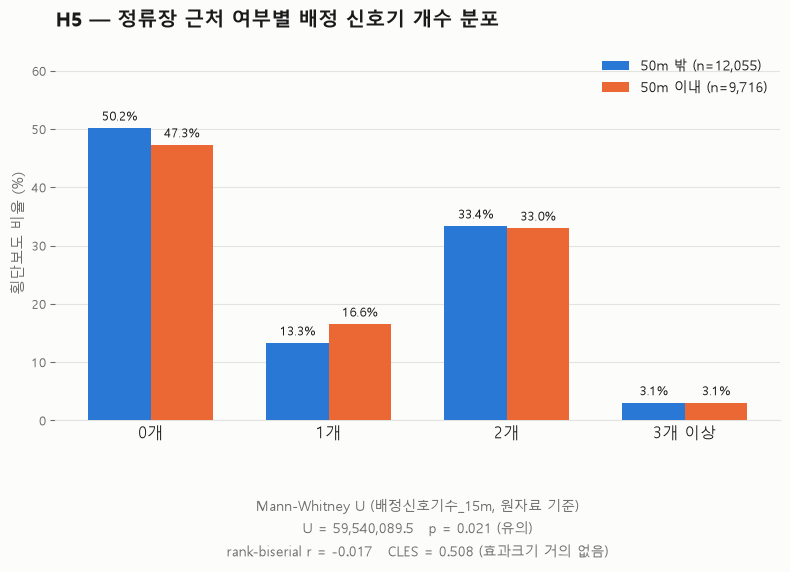

In [15]:
ok['cat'] = ok[col].clip(upper=3).map({0: '0개', 1: '1개', 2: '2개', 3: '3개 이상'})
cats = ['0개', '1개', '2개', '3개 이상']

pct0 = ok.loc[ok['정류장근처_50m'] == 0.0, 'cat'].value_counts(normalize=True).reindex(cats) * 100
pct1 = ok.loc[ok['정류장근처_50m'] == 1.0, 'cat'].value_counts(normalize=True).reindex(cats) * 100

x = np.arange(len(cats))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)
b0 = ax.bar(x - w / 2, pct0.values, width=w, color=BLUE, label=f'50m 밖 (n={len(g0):,})', zorder=3)
b1 = ax.bar(x + w / 2, pct1.values, width=w, color=ORANGE, label=f'50m 이내 (n={len(g1):,})', zorder=3)

for bars in (b0, b1):
    for bar in bars:
        h_ = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h_ + 0.8, f'{h_:.1f}%', ha='center', va='bottom', fontsize=9.5, color=INK)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11.5, color=INK)
ax.set_ylabel('횡단보도 비율 (%)', fontsize=11, color=MUTED)
ax.set_ylim(0, max(pct0.max(), pct1.max()) * 1.28)
ax.set_title('H5 — 정류장 근처 여부별 배정 신호기 개수 분포',
             fontsize=14.5, fontweight='bold', color=INK, loc='left', pad=14)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)
ax.legend(frameon=False, fontsize=10, loc='upper right', labelcolor=INK)

stat_text = (
    "Mann-Whitney U (배정신호기수_15m, 원자료 기준)\n"
    f"U = {u_stat:,.1f}   p = {p_mw:.3f} (유의)\n"
    f"rank-biserial r = {r_rb:.3f}   CLES = {cles:.3f} (효과크기 거의 없음)"
)
ax.text(0.5, -0.20, stat_text, transform=ax.transAxes, ha='center', va='top',
        fontsize=10, color=MUTED, linespacing=1.6)

plt.tight_layout()
plt.savefig('figures/h5/10_H5_신호기개수_분포.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

## 7. H8 — 고밀도 구간에서도 음향신호기 없는 횡단보도가 가까이 있는가

**가설:** 음향신호기가 밀집한 구간에서도 음향신호기 없는 횡단보도가 근접해 있어, 설비의 밀집이 곧 통학로 전체의 안전을 뜻하지는 않는다.

**진행 순서:** (1) 음향신호기 있는/없는 횡단보도부터 정의 → (2) 고밀도 구간 정의 → (3) 고밀도 구간에서 최근접 음향신호기 없는 횡단보도까지 거리·존재 비율 계산. 이번엔 (1)만 하고, **이 가설은 여기서 일단 킵해둔다**(유의미성을 어떻게 검정할지는 추후 결정).

### 7-1. 음향신호기 있음/없음 횡단보도 정의

**규칙:** 각 횡단보도에서 가장 가까운 음향신호기까지의 거리(`음향신호기_최근접_m`)가 **15m 이내**면 "음향신호기 있음", 아니면 "음향신호기 없음"으로 정의한다.

이건 §2에서 만든 **단순 규칙**(`음향_단순_15m`)과 같다 — §3·§4·§6에서 썼던 **배정 규칙**(신호기 하나를 가장 가까운 횡단보도 한 곳에만 배정)과는 다르다. 배정 규칙은 "이 신호기가 어느 횡단보도 소속인가"를 정할 때 필요한 규칙이고, 여기서는 반대로 "이 횡단보도 근처에 신호기가 있는가"만 보면 되므로 단순 규칙이 더 맞다. 실제로 두 규칙은 2,392건(11%)에서 판정이 갈린다(배정 규칙이 더 엄격해서 "없음"이 더 많이 나옴).

In [16]:
print("음향신호기_최근접_m 기술통계:")
print(ok['음향신호기_최근접_m'].describe().round(2))
print()

ok['음향신호기있음'] = ok['음향_단순_15m'].astype(bool)
print("음향신호기 있음/없음 횡단보도 (15m 기준):")
print(ok['음향신호기있음'].value_counts())
print(f"음향신호기 있음 비율: {ok['음향신호기있음'].mean()*100:.1f}%")
print()

n_diff = (ok['음향_단순_15m'] != ok['음향_배정_15m']).sum()
print(f"단순 규칙과 배정 규칙 판정이 갈리는 횡단보도: {n_diff:,}건 ({n_diff/len(ok)*100:.1f}%)")

음향신호기_최근접_m 기술통계:
count    21771.00
mean        42.41
std         70.80
min          0.09
25%          7.92
50%         11.78
75%         32.66
max       1079.86
Name: 음향신호기_최근접_m, dtype: float64

음향신호기 있음/없음 횡단보도 (15m 기준):
음향신호기있음
True     13512
False     8259
Name: count, dtype: int64
음향신호기 있음 비율: 62.1%

단순 규칙과 배정 규칙 판정이 갈리는 횡단보도: 2,392건 (11.0%)


### 7-2. 현재까지 한 것 / 안 한 것

**한 것:** 음향신호기 있음/없음 횡단보도 정의(15m 기준), 그리고 서울 전체 기준 비율만 확인했다 — 있음 62.1%, 없음 37.9%.

**안 한 것 (§7 진행 순서의 (2), (3)):**
- 고밀도 구간을 아직 정의하지 않았다.
- 고밀도 구간에서 최근접 "음향신호기 없는" 횡단보도까지의 거리·존재 비율을 계산하지 않았다.
- 따라서 유의미성 검정(비교 대상 설정 포함)도 하지 않았다.

**→ H8은 이 상태로 보류.**

### H7 보완: 출입문 1개·0개 캠퍼스 재조사 (2026-09-22)

기존 카카오 수집 결과가 1개인 12곳을 먼저 조사하고, 0개인 34곳을 이어 조사했다. **수집 개수는 실제 출입문 총수가 아니다.** 추가 키워드·페이지 검색과 공식 안내, OSM 경계·도로·장벽 자료를 대조했다.

서울과기대·명지대·숙명여대, 건국대·서울교대·한국체대에서 추가 좌표 후보를 확보했다. 그러나 현행 보행 연결과 운영 여부를 모두 검증한 것은 아니므로 **분석용 원본에 병합하지 않았다.** 별도 하위캠퍼스, 병원 공유부지, 주차장 입구와 중복 문은 구분한다.

아래 표는 46곳 전부의 조사 상태다. `path_candidate_records`는 도로와 경계의 교차·접점 기록 수이며 문 개수가 아니다. `new_coordinate_candidates`도 검증 완료 수가 아니다. 공식 자료의 연도·열람 제한·좌표 미확정 등은 `findings`를 확인한다. **H7 유의미성 검정은 아직 실행하지 않는다.**

상세 근거: `data/h7/gate_audit_20260922/README.md`. 지도: 같은 폴더의 `gate_review_map.html`. 재생성: `python build_gate_audit.py` (저장된 자료만 읽으며 API를 호출하지 않음).

In [17]:
from pathlib import Path
import pandas as pd
from IPython.display import display, FileLink

gate_audit_root = Path('data/h7/gate_audit_20260922')
if not gate_audit_root.exists():
    gate_audit_root = Path('DartB_TOYPROJECT') / gate_audit_root
gate_audit = pd.read_csv(gate_audit_root / 'campus_audit.csv', dtype={'univ_id': str})
gate_review = pd.read_csv(gate_audit_root / 'reviewed_gate_candidates.csv', dtype={'univ_id': str})
assert len(gate_audit) == 46 and gate_audit['univ_id'].is_unique
print('기존 수집 개수에 따른 조사 대상:')
display(gate_audit.groupby('old_count').size().rename('캠퍼스 수'))
display(gate_audit[['univ_name', 'old_count', 'review_status', 'new_coordinate_candidates', 'findings']])
display(gate_review[['univ_name', 'name', 'status', 'analysis_ready']])
display(FileLink(str(gate_audit_root / 'gate_review_map.html')))

기존 수집 개수에 따른 조사 대상:


old_count
0    34
1    12
Name: 캠퍼스 수, dtype: int64

,univ_name,old_count,review_status,new_coordinate_candidates,findings
0,KAIST 서울캠퍼스,1,추가좌표검토,0,OSM 무명 경계 후보 1곳. 고등과학원 안내는 과거 자료라 현행 정문·후문 여부 ...
1,광운대학교,1,추가근거부족,0,공식 정문 안내는 있으나 두 번째 문 미확인. 광운고등학교 결과 제외.
2,덕성여자대학교,1,추가문좌표필요,0,공식 오시는 길에 정문·후문 구분. 기존 1개를 실제 총수로 볼 수 없음.
3,명지대학교 인문캠퍼스,1,추가좌표확보,1,기존 후문 외 카카오 입구 확보. 공식 정문 안내도의 출입구 1~3은 주차 동선과 ...
4,상명대학교 서울캠퍼스,1,추가근거부족,0,공식 접근 안내 확인. 두 번째 외부 보행 출입점은 미확인.
5,서경대학교,1,추가문좌표필요,0,2025년 공식 공사 안내에 정문·서문. 현재 운영과 서문 좌표 확인 필요.
6,서울과학기술대학교,1,추가좌표확보,2,창의문·협동문 카카오 좌표 및 OSM foot=yes 일치. 공사로 정문 동선 변동...
7,서울여자대학교 서울캠퍼스,1,추가문좌표필요,0,공식 박물관 안내에 정문·남문. 기숙사 안내의 후문과 남문 동일 여부 확인 필요.
8,세종대학교,1,추가문좌표필요,0,공식 오시는 길에서 세종초등학교 쪽 후문 안내 확인. 후문 좌표 필요.
9,숙명여자대학교,1,추가좌표확보,1,지혜문 좌표 확보. 제2창학캠퍼스 후문은 제1캠퍼스와 분리 보류. 2020년 공식 ...


,univ_name,name,status,analysis_ready
0,명지대학교 인문캠퍼스,명지대학교 입구,추가위치_보행미검증,False
1,서울과학기술대학교,서울과학기술대학교 창의문,명명문_OSM보행태그일치,False
2,서울과학기술대학교,서울과학기술대학교 협동문,명명문_OSM보행태그일치,False
3,숙명여자대학교,숙명여자대학교 지혜문,추가위치_보행미검증,False
4,숙명여자대학교,숙명여자대학교 제2창학캠퍼스 후문,별도하위캠퍼스_보류,False
5,가톨릭대학교 성의교정,가톨릭대학교 출입구,병원공유부지_보류,False
6,건국대학교 서울캠퍼스,건국대학교 건국문,명명문_현행보행미검증,False
7,건국대학교 서울캠퍼스,건국대학교 상허문,명명문_현행보행미검증,False
8,건국대학교 서울캠퍼스,건국대학교 일감문,명명문_현행보행미검증,False
9,건국대학교 서울캠퍼스,건국대학교 출입구4,번호문_보행미검증,False


C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\data\h7\gate_audit_20260922\gate_review_map.html

### H7 보완 2: 64곳 전체를 같은 기준으로 출입문 정의 (2026-09-22)

위 46곳 재조사에 이어, 기존에 문이 2개 이상 수집된 18곳도 **같은 기준**으로 다시 조사해 64곳 전체의 출입문 목록을 만들었다(`audit_all64.py`, 결과는 `data/h7/gate_audit_20260922/all64/`).

**기준(사용자 합의):** 캠퍼스 경계에서 외부 보행로와 내부 보행로가 이어지는 지점만 출입문으로 인정한다. 건물 출입구·차량 전용 출입구·같은 문의 다른 이름은 제외하고, 불확실하면 미확정으로 남긴다.

**문마다 근거 등급을 붙였다.**
- **A (공식명칭+좌표):** 대학 공식 자료(지도·공지)에 나온 문 이름과 좌표 POI 이름이 일치
- **B (좌표만):** 좌표는 있으나 공식 자료의 문 이름과 대응하지 않음(예: 숭실대 후문, 경희대 남문)
- **C (좌표 없음):** 공식 자료에 이름은 있으나 좌표를 못 찾음(예: 서울시립대 미래문·이음문·하늘문, 성균관대 동문)
- **보류:** 중복, 별도 하위캠퍼스, 병원 공유부지, 지하철 연결 통로(한양대 애지문)

**18곳에서 새로 확보한 좌표:** 동국대 혜화문, 서강대 남문, 이화여대 북아현문(모두 A). 규칙은 "학교 이름 + 공식 문 이름이 모두 들어가고 카테고리가 입출구인 카카오 POI"이고, 주차장·부속학교·병원 이름은 뺐다.

**캠퍼스 단위 보류 17곳:** 대학원 중심·건물형 시설, 병원 공유부지, 경계 미확정, 주소 불일치. 이 17곳은 표본에 넣을지부터 정해야 한다.

**모든 문은 `analysis_ready=False`다.** 이름과 좌표를 확보한 것과 현재 실제로 걸어서 드나들 수 있는지 확인한 것은 다르다. 아래 표의 A·B 개수는 H7 표본 크기를 가늠하기 위한 것이고, **H7 검정은 아직 하지 않았다.**

In [18]:
all64_root = gate_audit_root / 'all64'
campus64 = pd.read_csv(all64_root / 'campus_audit_all64.csv', dtype={'univ_id': str})
gates64 = pd.read_csv(all64_root / 'gate_definition_all64.csv', dtype={'univ_id': str})
assert len(campus64) == 64 and campus64['univ_id'].is_unique

unit_ok = campus64[~campus64['unit_hold']]
ab = unit_ok['gates_A'] + unit_ok['gates_B']
print(f"64곳 중 캠퍼스 단위 보류: {campus64['unit_hold'].sum()}곳, 단위 문제 없음: {len(unit_ok)}곳")
print(f"  A 문만 셀 때 2개 이상: {(unit_ok['gates_A'] >= 2).sum()}곳")
print(f"  A+B 문을 셀 때 2개 이상: {(ab >= 2).sum()}곳  (1개: {(ab == 1).sum()}곳, 0개: {(ab == 0).sum()}곳)")
print(f"  (참고) 기존 카카오 수집 2개 이상: {(campus64['old_count'] >= 2).sum()}곳")
print()
print("문 근거 등급별 개수:")
display(gates64['tier'].value_counts().rename('문 수'))

cols = ['univ_name', 'old_count', 'gates_A', 'gates_B', 'gates_C_no_coordinate', 'gates_held', 'official_named_gates']
display(unit_ok.assign(AB=ab).sort_values(['AB', 'gates_A'], ascending=False)[cols])
display(campus64[campus64['unit_hold']][['univ_name', 'review_status', 'findings']])
display(FileLink(str(all64_root / 'gate_review_map_all64.html')))

64곳 중 캠퍼스 단위 보류: 17곳, 단위 문제 없음: 47곳
  A 문만 셀 때 2개 이상: 14곳
  A+B 문을 셀 때 2개 이상: 24곳  (1개: 9곳, 0개: 14곳)
  (참고) 기존 카카오 수집 2개 이상: 18곳

문 근거 등급별 개수:


tier
A_공식명칭+좌표      45
B_좌표만          31
C_공식명칭_좌표없음    14
제외_보류           5
Name: 문 수, dtype: int64

,univ_name,old_count,gates_A,gates_B,gates_C_no_coordinate,gates_held,official_named_gates
1,연세대학교 신촌캠퍼스,5,5,0,0,0,정문 / 동문 / 서문 / 남문 / 북문
0,숭실대학교,5,4,1,0,0,정문 / 중문 / 남문 / 북문
35,건국대학교 서울캠퍼스,0,3,2,0,2,건국문 / 상허문 / 일감문
6,고려대학교 서울캠퍼스,2,0,4,0,0,NaN
4,중앙대학교 서울캠퍼스,3,3,0,0,0,정문 / 중문 / 후문
8,동국대학교 서울캠퍼스,2,3,0,0,0,정문 / 후문 / 혜화문
10,서강대학교,2,3,0,0,0,정문 / 후문 / 남문
15,이화여자대학교,2,3,0,3,0,정문 / 후문 / 서문 / 북문 / 북아현문 / 공학관문
24,서울과학기술대학교,1,3,0,0,0,정문 / 창의문 / 협동문
2,경희대학교 서울캠퍼스,3,2,1,0,0,정문 / 후문


,univ_name,review_status,findings
30,KAIST 도곡캠퍼스,표본단위검토,도곡 교육시설의 건물 출입구와 캠퍼스 경계 출입문 구분 필요.
32,가톨릭대학교 성의교정,공유부지검토,카카오 출입구 1곳. 공식 안내에 학교 후문과 병원 문이 혼재하므로 귀속 및 보행 ...
36,국방대학교 서울캠퍼스,표본단위검토,서울 소재 시설의 현재 교육 기능과 표본 포함 기준 확인 필요. 군 시설 접근 제한...
37,덕성여자대학교 종로운현캠퍼스,표본단위검토,종로 교육시설과 운현초등학교 등 인접 부지의 경계 분리 필요.
39,백석대학교 서울캠퍼스,표본단위검토,서울 대학원 시설로 안내. 대학원 중심 시설 포함 여부를 기존 제외 기준과 일치시켜...
40,백석예술대학교,경계확인필요,학교 소재지는 확인되나 건물군과 캠퍼스 외부 경계 미확정. 출입문 0개로 해석 금지.
41,서울과학종합대학교,표본단위검토,정식 명칭 서울과학종합대학원대학교. 대학원대학 제외 기준을 적용할지 검토.
44,서울대학교 연건캠퍼스,공유부지검토,검색된 서울대학교병원 정문·후문은 대학 소속 보행 출입문으로 자동 편입하지 않음. ...
45,서울예술대학교 남산캠퍼스,경계확인필요,남산캠퍼스의 현재 이용 구역·경계·보행 문을 뒷받침하는 공식 근거 부족.
49,이화여자대학교 의과대학,공유부지검토,의대 건물 B2 출입 안내와 캠퍼스 경계 문을 구분. 병원과 공유하는 외부 접근 구...


C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\data\h7\gate_audit_20260922\all64\gate_review_map_all64.html

### H7 정리: 64개 대학 중 출입문이 몇 개씩 나왔나

**대상:** 카카오 "대학교" 검색으로 찾은 서울 81곳에서 경기도 캠퍼스, 대학원대학교, 정규 대학이 아닌 곳, 학과·건물 단위 중복을 뺀 **64개 캠퍼스**.

**출입문으로 센 기준**
1. 카카오에서 "학교명 + 정문/후문/동문/서문/남문/북문/중문"으로 검색한 결과 중 아래 조건을 모두 만족하는 것
   - 분류가 "교통,수송 > 입출구"
   - 이름에 문 이름이 있고, 다른 대학 이름은 없음
   - 학교 대표 지점에서 가까움 (이름에 학교명이 있으면 2km, 없으면 400m 이내)
2. 대학 공식 캠퍼스 지도·공지와 대조해서 추가로 확보한 좌표 (예: 건국대 건국문, 서울과기대 창의문, 동국대 혜화문)
3. 이름에 '…문'이 들어간 지점을 다시 찾아 추가한 것 (고려대 정경관후문·의과대학 후문)
4. 주차장·부속학교·병원 문, 중복, 다른 캠퍼스 소속, 지하철 연결 통로는 **개수에서 뺌(보류)**

**등급**
- **A:** 대학 공식 자료에 나온 문 이름과 좌표의 이름이 일치
- **B:** 좌표는 있지만 공식 문 이름과 맞지 않음
- C(공식 이름만 있고 좌표 없음)는 위치를 모르므로 개수에 넣지 않음

**캠퍼스 단위 보류 17곳:** 대학원 중심·건물형 시설, 병원 공유부지, 캠퍼스 경계 미확정, 주소 불일치인 곳. 표본에 넣을지부터 정해야 해서 아래 표에서는 따로 뺐다.

**읽는 법:** 한 학교 안에서 문끼리 비교(H7)하려면 문이 **2개 이상** 있어야 한다. 아래 개수는 현장에서 실제로 드나들 수 있는지 확인하기 전의 개수다.

In [19]:
from pathlib import Path
import pandas as pd
from IPython.display import display

h7_root = Path('data/h7/gate_audit_20260922/all64')
h7 = pd.read_csv(h7_root / 'campus_audit_all64.csv', dtype={'univ_id': str})
h7['A'] = h7['gates_A']
h7['A+B'] = h7['gates_A'] + h7['gates_B']
ok7 = h7[~h7['unit_hold']]
held7 = h7[h7['unit_hold']]
labels7 = ['0개', '1개', '2개', '3개', '4개', '5개 이상']

print(f"64개 캠퍼스 = 캠퍼스 단위 문제 없음 {len(ok7)}곳 + 캠퍼스 단위 보류 {len(held7)}곳")
print()

# 1) 출입문 수별 대학 수
def by_count(col):
    s = ok7[col].clip(upper=5).value_counts().reindex(range(6), fill_value=0)
    s.index = labels7
    return s

dist7 = pd.DataFrame({'A 등급 문만 셀 때': by_count('A'), 'A+B 등급 문을 셀 때': by_count('A+B')})
dist7.index.name = '출입문 수'
print("[표 1] 출입문 수별 대학 수 (캠퍼스 단위 문제 없는 47곳)")
display(dist7)

# 2) H7 비교 가능 여부로 묶기
summary7 = pd.DataFrame({
    'A 등급 문만 셀 때': [(ok7['A'] >= 2).sum(), (ok7['A'] == 1).sum(), (ok7['A'] == 0).sum()],
    'A+B 등급 문을 셀 때': [(ok7['A+B'] >= 2).sum(), (ok7['A+B'] == 1).sum(), (ok7['A+B'] == 0).sum()],
}, index=['문 2개 이상 (H7 비교 가능)', '문 1개', '문 0개'])
print("[표 2] H7에 쓸 수 있는 대학 수")
display(summary7)

# 3) 출입문 수별 대학 이름 (A+B 기준)
names7 = ok7['univ_name'].str.replace(r' (서울|인문사회과학|신촌|관악|돈암수정|인문)캠퍼스', '', regex=True)
list7 = (ok7.assign(대학=names7, 출입문수=ok7['A+B'].clip(upper=5).map(dict(enumerate(labels7))))
            .groupby('출입문수', sort=False)['대학']
            .agg(대학수='size', 대학=lambda s: ', '.join(s))
            .reindex(labels7).dropna().astype({'대학수': int}))
print("[표 3] A+B 등급 기준, 출입문 수별 대학 목록")
display(list7)

print("[표 4] 캠퍼스 단위 보류 17곳")
display(held7[['univ_name', 'review_status']].rename(columns={'univ_name': '캠퍼스', 'review_status': '보류 이유'}).reset_index(drop=True))

64개 캠퍼스 = 캠퍼스 단위 문제 없음 47곳 + 캠퍼스 단위 보류 17곳

[표 1] 출입문 수별 대학 수 (캠퍼스 단위 문제 없는 47곳)


,A 등급 문만 셀 때,A+B 등급 문을 셀 때
출입문 수,,
0개,27,14
1개,6,9
2개,6,12
3개,6,8
4개,1,1
5개 이상,1,3


[표 2] H7에 쓸 수 있는 대학 수


,A 등급 문만 셀 때,A+B 등급 문을 셀 때
문 2개 이상 (H7 비교 가능),14,24
문 1개,6,9
문 0개,27,14


[표 3] A+B 등급 기준, 출입문 수별 대학 목록


,대학수,대학
출입문수,,
0개,14,"가톨릭대학교 성신교정, 감리교신학대학교, 강서대학교, 동덕여자대학교, 서울기독대학교..."
1개,9,"KAIST, 광운대학교, 덕성여자대학교, 상명대학교, 서경대학교, 서울여자대학교, ..."
2개,12,"경기대학교, 국민대학교, 삼육대학교, 서울대학교, 서울시립대학교, 성균관대학교, 성..."
3개,8,"경희대학교, 장로회신학대학교, 중앙대학교, 동국대학교, 서강대학교, 이화여자대학교,..."
4개,1,고려대학교
5개 이상,3,"숭실대학교, 연세대학교, 건국대학교"


[표 4] 캠퍼스 단위 보류 17곳


,캠퍼스,보류 이유
0,KAIST 도곡캠퍼스,표본단위검토
1,가톨릭대학교 성의교정,공유부지검토
2,국방대학교 서울캠퍼스,표본단위검토
3,덕성여자대학교 종로운현캠퍼스,표본단위검토
4,백석대학교 서울캠퍼스,표본단위검토
5,백석예술대학교,경계확인필요
6,서울과학종합대학교,표본단위검토
7,서울대학교 연건캠퍼스,공유부지검토
8,서울예술대학교 남산캠퍼스,경계확인필요
9,이화여자대학교 의과대학,공유부지검토


### H7 출입문 정의 — 여기서 마무리: 한계점과 추후 과제 (2026-09-22)

**지금 상태:** 64개 캠퍼스 중 캠퍼스 단위 문제가 없는 47곳에서, A+B 등급 문이 2개 이상인 **24곳(출입문 67개)을 H7 표본으로 확정**했다. 출입문을 정하는 작업은 여기서 멈춘다. **H7 검정은 아직 하지 않았다.**

#### 한계점
1. **실제로 걸어서 드나들 수 있는지 확인하지 않았다.** 모든 문은 카카오·OSM에 등록된 지점일 뿐이다. 운영 시간, 폐쇄, 차량 전용 여부를 지도·로드뷰·현장으로 확인하지 않았다(`analysis_ready=False`).
2. **좌표가 캠퍼스 경계 위가 아니다.** 카카오 핀 위치를 그대로 썼다. 정의(보행로가 캠퍼스 경계를 지나는 지점)와 몇십 m 차이가 날 수 있고, 문 주변 음향신호기를 셀 때 결과에 영향을 줄 수 있다.
3. **B 등급 문 31개는 대학 공식 자료의 문 이름과 맞지 않는다.** 일부는 잘못된 문일 수 있다. 예를 들어 숭실대 후문은 카카오와 OSM 위치가 약 330m 다르고, 공식 안내에는 정문·중문·남문·북문 4개만 나온다.
4. **카카오에 등록되지 않은 문은 빠졌다.** 문이 1개인 9곳과 0개인 14곳은 문이 실제로 없어서가 아니라 데이터에 없어서 빠졌다. 그래서 표본이 크고 잘 알려진 대학 쪽으로 치우쳤을 수 있다.
5. **공식 자료 근거의 질이 고르지 않다.** 오래된 자료(2005·2011·2018년), 다시 열어보지 못한 공지, 주차 안내가 섞여 있다. 학교별 근거 URL은 `campus_audit_all64.csv`에 있다.
6. **캠퍼스 단위 보류 17곳의 포함 기준을 정하지 않았다.** 대학원 중심·건물형 시설, 병원 공유부지, 경계 미확정, 주소 불일치인 곳이다.
7. **OSM 경계 교차점과 문·차단기 노드는 참고용으로만 계산했다.** 이름이 없어 공식 문과 맞춰볼 수 없어서 채택하지 않았다.
8. **학교마다 문 수가 2~5개로 다르다.** 문이 많은 학교일수록 문별 개수 차이(CV)가 크게 나올 수 있어, 검정할 때 이 영향을 고려해야 한다.

#### 추후 해야 할 것
1. **표본 24곳의 문 67개를 지도·로드뷰로 확인**해서 실제 보행 출입문인지, 위치가 맞는지 표시한다. B 등급 문과 숭실대 후문 위치 충돌부터 확인한다.
2. 좌표를 캠퍼스 경계 위 실제 보행 진입점으로 옮길지 정한다.
3. **표본을 늘리려면** 공식 자료에 이름은 있지만 좌표가 없는 문의 좌표를 찾는다.
   - 문 1개라서 빠진 곳: 덕성여대 정문, 서경대 정문, 서울여대 정문·남문, 세종대 후문
   - 이미 표본인 곳: 서울시립대 미래문·이음문·하늘문, 성균관대 동문, 이화여대 서문·북문·공학관문, 한양대 사근동출입로·건축관출입로
4. **OSM 후보를 하나씩 검토한다.** 감리교신학대 차단기 2개, 한양여대·한예종 석관동 경계 교차 각 13건, 연세대 경계 위 쪽문·기숙사 문, 서울대 나들문(캠퍼스 안쪽 문이라는 판단 재확인)이 대상이다.
5. 캠퍼스 단위 보류 17곳을 넣을지 하나의 규칙으로 정한다.
6. **검정 전에 정할 것:** 출입문과 음향신호기를 연결하는 규칙(반경 몇 m, 거리 반영 여부), 유의미성 검정 방법, 문 수 차이를 반영하는 방법.
7. 결과를 보고할 때 위 한계, 특히 4번(표본 쏠림)을 함께 적는다.

## 8. H7 검정 — 설계

**질문:** 같은 학교 안에서 출입문마다 주변 음향신호기 개수가 크게 다른가. **표본:** 24곳, 출입문 67개(A+B 등급).

**① 출입문과 음향신호기 연결: 반경 방식**
- 문에서 **반경 300m** 안의 음향신호기를 그 문의 것으로 센다. 200m·400m로 민감도를 확인한다.
- 200m는 문 67개 중 26개에서 신호기가 0개라 검정이 되는 학교가 9곳뿐이어서 기본값으로 쓰지 않았다.
- 거리는 직선거리(EPSG:5186)다. 실제 걸어가는 거리를 쓰려면 24곳 보행망을 새로 만들어야 해서 하지 않았다.
- 문끼리 가까우면 같은 신호기를 두 문이 겹쳐 셀 수 있다(한계).

**② 세는 값: 개수와 설치 비율 둘 다**
- 문별 **음향신호기 개수**가 주 지표다.
- 가설표의 주의점("개수는 주변 횡단보도 수에 좌우됨")을 반영해, 문 주변 **횡단보도 수**와 **그중 음향신호기가 있는 비율**도 같이 계산한다.

**③ 격차 크기: 변동계수(CV)**
- 학교마다 CV = 문별 개수의 표준편차 ÷ 평균. 값이 클수록 문끼리 차이가 크다.

**④ 유의성: 무작위 배치와 비교 (몬테카를로)**
- 귀무가설: 신호기는 **문 주변 횡단보도 수에 비례해서** 나뉜다(문 위치와 무관).
- 그 비율대로 신호기를 무작위로 2만 번 다시 나눠보고, 카이제곱 통계량이 실제보다 큰 경우의 비율을 p값으로 쓴다. 기대값이 작아 일반 카이제곱 근사가 약해서 이 방식을 썼다.
- 신호기가 5개 미만인 학교는 검정하지 않는다. 학교 수만큼 반복 검정하므로 **Holm 보정**을 적용한다.

계산은 `h7_gate_signal.py`에 있고, 결과는 `data/h7/h7_gate_counts_*.csv`, `h7_campus_test_*.csv`에 저장된다.

In [20]:
import h7_gate_signal as h7

h7_inputs = h7.load_inputs()
h7_counts, h7_result = h7.run(radius=300, inputs=h7_inputs)

print(h7.summarize(h7_result, 300))
print()
cols = ['대학', '문수', '신호기합', '문별_신호기수', 'CV', 'CV_무작위_중앙값', 'p', 'p_holm', '유의']
display(h7_result[cols].round(3))

{'반경_m': 300, '검정한_대학': 20, '유의_대학': 1, 'CV_중앙값': 0.82, 'CV_0.5이상_대학': 14}



,대학,문수,신호기합,문별_신호기수,CV,CV_무작위_중앙값,p,p_holm,유의
0,연세대학교 신촌캠퍼스,5,39,"27, 0, 2, 8, 2",1.429,0.995,0.174,1.000,False
1,삼육대학교,2,2,"2, 0",1.414,NaN,NaN,NaN,None
2,서울대학교 관악캠퍼스,2,2,"2, 0",1.414,NaN,NaN,NaN,None
3,성균관대학교 인문사회과학캠퍼스,2,6,"6, 0",1.414,1.414,1.000,1.000,False
4,서울시립대학교,2,13,"13, 0",1.414,1.197,0.620,1.000,False
5,홍익대학교 서울캠퍼스,2,27,"24, 3",1.100,0.786,0.177,1.000,False
6,중앙대학교 서울캠퍼스,3,13,"4, 9, 0",1.041,0.581,0.002,0.049,True
7,한양대학교 서울캠퍼스,2,27,"23, 4",0.995,0.995,1.000,1.000,False
8,서울과학기술대학교,3,17,"3, 2, 12",0.972,0.509,0.138,1.000,False
9,이화여자대학교,3,11,"7, 4, 0",0.958,1.033,0.760,1.000,False


In [21]:
sens = [h7.summarize(h7.run(radius=r, inputs=h7_inputs)[1], r) for r in (200, 300, 400)]
print('[민감도] 반경을 바꿨을 때')
display(pd.DataFrame(sens))

a_only = h7.run(radius=300, tiers=('A_공식명칭+좌표',), save=False, inputs=h7_inputs)[1]
print('[민감도] A 등급 문만 썼을 때 (14곳)')
display(pd.DataFrame([h7.summarize(a_only, 300)]))

[민감도] 반경을 바꿨을 때


,반경_m,검정한_대학,유의_대학,CV_중앙값,CV_0.5이상_대학
0,200,14,0,1.06,15
1,300,20,1,0.82,14
2,400,22,0,0.45,12


[민감도] A 등급 문만 썼을 때 (14곳)


,반경_m,검정한_대학,유의_대학,CV_중앙값,CV_0.5이상_대학
0,300,13,1,0.98,10


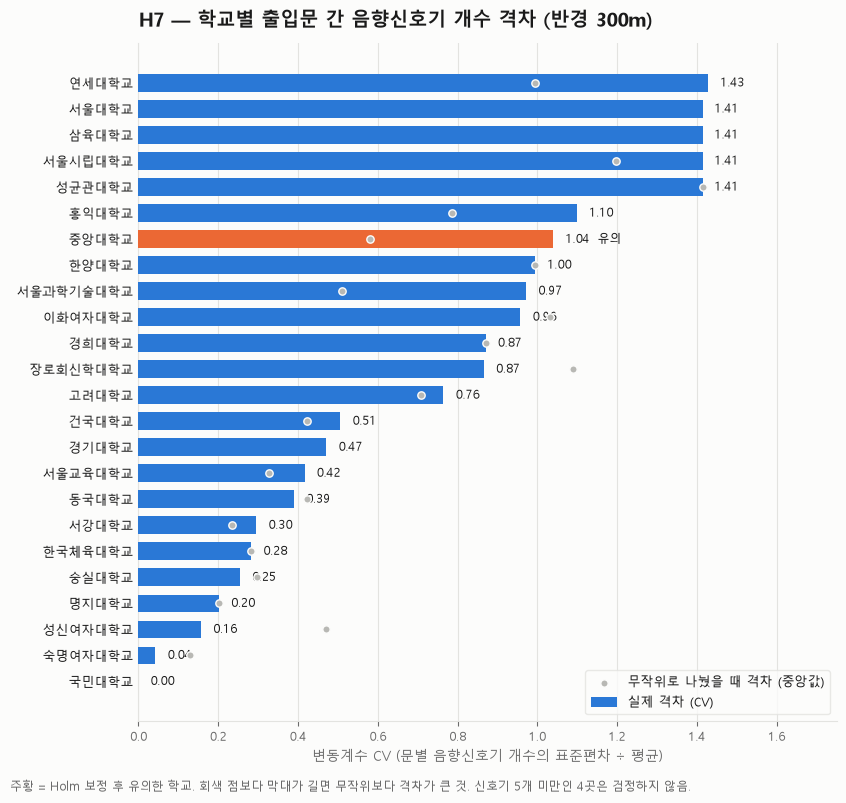

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
BG, BLUE, ORANGE, GRAY, INK, MUTED, GRID = '#fcfcfb', '#2A78D6', '#EB6834', '#B8B8B4', '#1a1a1a', '#6b6b6b', '#e3e3e0'

r7 = h7_result.sort_values('CV')
name7 = r7['대학'].str.replace(r' (서울|인문사회과학|신촌|관악|돈암수정|인문)캠퍼스', '', regex=True)
fig, ax = plt.subplots(figsize=(8.5, 8), facecolor=BG)
ax.set_facecolor(BG)
y7 = np.arange(len(r7))
ax.barh(y7, r7['CV'], height=0.68, zorder=3, label='실제 격차 (CV)',
        color=[ORANGE if s is True else BLUE for s in r7['유의'].fillna(False)])
ax.scatter(r7['CV_무작위_중앙값'], y7, color=GRAY, s=28, zorder=4, edgecolor=BG, linewidth=1,
           label='무작위로 나눴을 때 격차 (중앙값)')
for i, row in enumerate(r7.itertuples()):
    ax.text(row.CV + 0.03, i, f"{row.CV:.2f}" + ("  유의" if row.유의 is True else ""),
            va='center', fontsize=8.5, color=INK)
ax.set_yticks(y7)
ax.set_yticklabels(name7, fontsize=9.5, color=INK)
ax.set_xlabel('변동계수 CV (문별 음향신호기 개수의 표준편차 ÷ 평균)', fontsize=10, color=MUTED)
ax.set_xlim(0, 1.75)
ax.set_title('H7 — 학교별 출입문 간 음향신호기 개수 격차 (반경 300m)',
             fontsize=13.5, fontweight='bold', color=INK, loc='left', pad=12)
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='x', colors=MUTED, labelsize=9)
ax.tick_params(axis='y', length=0)
ax.legend(frameon=True, facecolor=BG, edgecolor=GRID, fontsize=9.5, loc='lower right', labelcolor=INK)
fig.text(0.01, 0.005, '주황 = Holm 보정 후 유의한 학교. 회색 점보다 막대가 길면 무작위보다 격차가 큰 것. 신호기 5개 미만인 4곳은 검정하지 않음.',
         fontsize=8.5, color=MUTED)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig('figures/h7/02_학교별_CV.png', dpi=150, facecolor=BG)
plt.show()

### 8-1. 주 분석 변경: 학교별 검정 → 전체를 한 번에 검정

학교마다 따로 검정하면 문이 2~3개뿐이라 무작위로 나눠도 CV가 1 근처까지 나오고, 24번 반복 검정한 Holm 보정까지 겹쳐 유의한 곳이 1곳(중앙대)뿐이었다. 이건 격차가 없다는 뜻이 아니라 **학교 하나하나로는 판단할 자료가 부족하다**는 뜻이다.

그래서 **문 67개를 모아 한 번만 검정**하는 방식으로 바꿨다. 각 학교의 신호기 합은 그대로 두고 문에 나누는 방식만 귀무가설로 둔 뒤, 학교별 카이제곱 통계량을 모두 더해 하나의 값으로 만들어 무작위 배치와 비교한다. 검정이 한 번이므로 다중비교 보정이 필요 없고, 표본이 67개라 검정력이 높다. 어느 학교인지는 말할 수 없고 "학교 안 문끼리 차이가 있는가"만 답한다.

**기준(귀무가설)을 두 가지로 나눠서 본다.** 무엇을 "격차"로 볼지에 따라 답이 달라지기 때문이다.

| 기준 | 귀무가설 | 이 기준으로 유의하면 |
|---|---|---|
| **문마다 같음** | 신호기가 문마다 같은 수로 나뉜다 | 이용자가 어느 문으로 다니냐에 따라 만나는 신호기 수가 다르다 |
| **횡단보도수 비례** | 신호기가 문 주변 횡단보도 수에 비례해 나뉜다 | 횡단보도 수로 설명되지 않는 불균형이 있다 (설치의 편중) |

보조 지표로 **문 주변 횡단보도 중 음향신호기가 있는 비율**이 같은 학교 안에서 문마다 다른지도 같은 방식으로 검정한다(이항 추출).

In [23]:
pooled = []
for R in (200, 300, 400):
    counts_R = h7.run(radius=R, save=(R == 300), inputs=h7_inputs)[0]
    for basis in ('uniform', 'crosswalk'):
        pooled.append({'반경_m': R, **h7.pooled_test(counts_R, basis=basis)})
    if R == 300:
        rate_test = h7.pooled_rate_test(counts_R)

print('[주 분석] 문 67개를 모아 한 번에 검정')
display(pd.DataFrame(pooled))
print('[보조] 문 주변 횡단보도 중 음향신호기 비율이 문마다 다른가 (반경 300m)')
display(pd.DataFrame([rate_test]))

[주 분석] 문 67개를 모아 한 번에 검정


,반경_m,기준,대학,문,카이제곱합,자유도,관측/기대 비율,무작위 카이제곱합 중앙값,p
0,200,문마다 같음,21,60,197.5,39,5.07,38.4,0.0000
1,200,횡단보도수 비례,21,60,43.1,39,1.10,38.2,0.2943
2,300,문마다 같음,24,67,207.2,43,4.82,42.4,0.0000
3,300,횡단보도수 비례,24,67,50.2,43,1.17,42.1,0.2112
4,400,문마다 같음,24,67,270.4,43,6.29,42.5,0.0000
5,400,횡단보도수 비례,24,67,41.9,43,0.97,42.2,0.5132


[보조] 문 주변 횡단보도 중 음향신호기 비율이 문마다 다른가 (반경 300m)


,지표,대학,자유도,관측 통계량,무작위 중앙값,p
0,횡단보도 중 신호기 비율,16,28,35.6,43.4,0.83255


### 8-2. H7 결과

| 기준 | 반경 200m | 반경 300m | 반경 400m |
|---|---|---|---|
| **문마다 같음** | p < 0.0001, 관측/기대 5.1배 | p < 0.0001, **4.8배** | p < 0.0001, 6.3배 |
| **횡단보도수 비례** | p = 0.29, 1.10배 | p = 0.21, **1.17배** | p = 0.51, 0.97배 |
| 보조: 신호기 설치 비율 | — | p = 0.83 (차이 없음) | — |

- **문마다 신호기 개수는 분명히 다르다.** "문마다 같다"를 기준으로 하면 관측된 차이가 무작위의 4.8~6.3배이고, 반경을 바꿔도 p < 0.0001로 일정하다. **H7의 "같은 학교 안에서도 출입문마다 접근성 격차가 클 것이다"는 지지된다.**
- **그 격차는 문 주변 횡단보도 수 차이로 설명된다.** 횡단보도 수에 비례한다는 기준으로 보면 관측/기대가 1.0 근처이고 유의하지 않다(p = 0.21~0.51). 즉 신호기가 특정 문에 편중되게 설치된 것이 아니라, **문마다 마주치는 횡단보도 자체가 다르다.**
- 보조 지표도 같은 방향이다. 문 주변 횡단보도 중 신호기가 있는 비율은 같은 학교 안에서 문마다 다르지 않다(p = 0.83).
- 학교별로는 24곳 중 Holm 보정 후 중앙대 1곳만 유의했다(8절 표). 학교 하나 단위로는 자료가 부족해서이지, 격차가 없어서가 아니다.

**정리:** 어느 문으로 다니느냐에 따라 만나는 음향신호기 수는 실제로 크게 다르다. 다만 그 차이는 신호기 설치의 편중이 아니라 문 주변 보행 환경(횡단보도 수)의 차이에서 온다. 개선 방향을 말한다면 "특정 문에 신호기를 더 놓자"보다 "횡단보도가 적은 문 쪽 통학로를 함께 봐야 한다"가 된다.

**한계:** 문 좌표가 캠퍼스 경계가 아니라 카카오 핀 위치이고, 반경은 직선거리다. 문끼리 가까우면 같은 신호기를 겹쳐 세며, 실제 보행 가능 여부는 확인하지 않았다(7절 한계 목록).

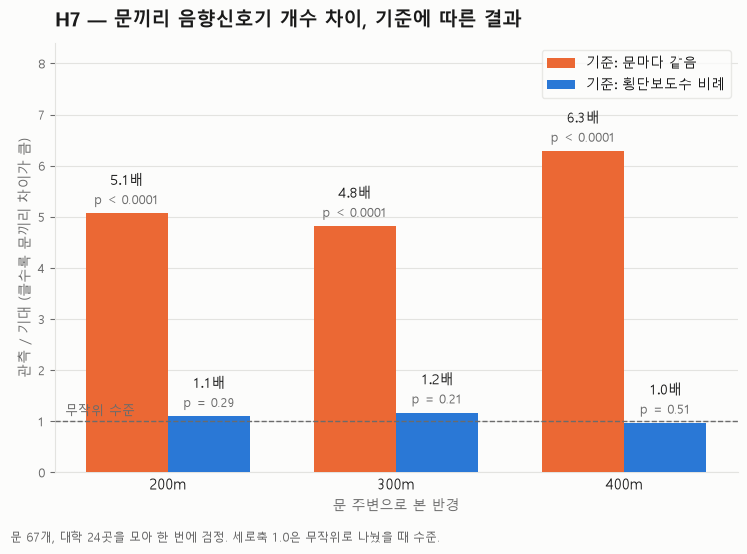

In [24]:
labels = ['200m', '300m', '400m']
pooled_df = pd.DataFrame(pooled)
uniform = pooled_df[pooled_df['기준'] == '문마다 같음'].set_index('반경_m')
crosswalk = pooled_df[pooled_df['기준'] == '횡단보도수 비례'].set_index('반경_m')

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(3)
w = 0.36
b1 = ax.bar(x - w / 2, uniform['관측/기대 비율'], width=w, color=ORANGE, zorder=3, label='기준: 문마다 같음')
b2 = ax.bar(x + w / 2, crosswalk['관측/기대 비율'], width=w, color=BLUE, zorder=3, label='기준: 횡단보도수 비례')
for bars, src in ((b1, uniform), (b2, crosswalk)):
    for bar, (_, row) in zip(bars, src.iterrows()):
        p_txt = 'p < 0.0001' if row['p'] < 0.0001 else 'p = {:.2f}'.format(row['p'])
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                '{:.1f}배'.format(bar.get_height()), ha='center', va='bottom', fontsize=10, color=INK)
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.12,
                p_txt, ha='center', va='bottom', fontsize=9, color=MUTED)
ax.axhline(1, color=MUTED, linestyle='--', linewidth=1, zorder=4)
ax.text(-0.45, 1.12, '무작위 수준', fontsize=9, color=MUTED, ha='left')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color=INK)
ax.set_xlabel('문 주변으로 본 반경', fontsize=10, color=MUTED)
ax.set_ylabel('관측 / 기대 (클수록 문끼리 차이가 큼)', fontsize=10, color=MUTED)
ax.set_ylim(0, 8.4)
ax.set_title('H7 — 문끼리 음향신호기 개수 차이, 기준에 따른 결과', fontsize=13.5, fontweight='bold', color=INK, loc='left', pad=12)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)
ax.legend(frameon=True, facecolor=BG, edgecolor=GRID, fontsize=10, loc='upper right', labelcolor=INK)
fig.text(0.01, 0.005, '문 67개, 대학 24곳을 모아 한 번에 검정. 세로축 1.0은 무작위로 나눴을 때 수준.', fontsize=8.5, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig('figures/h7/03_전체검정_기준별.png', dpi=150, facecolor=BG)
plt.show()

## 9. 곁가지 탐색 — 횡단보도 밀도는 보행 위험과 관련 있는가

**어쩌다 이 질문을 하게 됐나:** §8-2에서 H7을 검정하면서, 문마다 신호기 개수가 다른 이유가 "신호기 설치 편중"이 아니라 "**문 주변 횡단보도 수 자체가 다르기 때문**"이라는 결론이 나왔다. 그러면 자연스럽게 다음 질문이 생긴다 — 횡단보도 수가 신호기 배치를 정하는 배경 변수라면, **횡단보도 수 자체는 보행 위험(난이도)과 관련이 있는가?** 지금까지 H5·H7은 전부 "신호기 유무"를 중심으로 봤는데, 이 질문은 그보다 한 단계 앞의 변수를 본다.

이 프로젝트의 궁극적 목적(어떤 변수가 시각장애인 보행 난이도에 큰 영향을 끼치는지, 그 양상이 어떤지)에 맞춰, 정식 가설(H5~H8)과는 별도로 짧게 탐색한다.

In [25]:
import pandas as pd
from scipy.stats import spearmanr

acc_693 = pd.read_csv('data/seoul_relationship_eda/seoul_site_profiles.csv', encoding='utf-8-sig')

def effect_label(r):
    a = abs(r)
    return '무시할 만함' if a < 0.1 else '작음' if a < 0.3 else '중간' if a < 0.5 else '큼'

rows = []
for x in ['횡단보도수_0m', '횡단보도수_50m', '횡단보도수_100m', '교차로수']:
    for y in ['사고건수', '사상자수', '사고당_사상자수', '사망중상_비율']:
        d = acc_693[[x, y]].dropna()
        rho, p = spearmanr(d[x], d[y])
        rows.append({'설명변수': x, '결과변수': y, 'n': len(d), 'rho': round(rho, 3),
                     'p': round(p, 4), '유의(0.05)': p < 0.05, '효과크기': effect_label(rho)})
first_try = pd.DataFrame(rows)
print(f"유의한 조합: {first_try['유의(0.05)'].sum()} / {len(first_try)}")
display(first_try)

유의한 조합: 0 / 16


,설명변수,결과변수,n,rho,p,유의(0.05),효과크기
0,횡단보도수_0m,사고건수,693,0.048,0.2024,False,무시할 만함
1,횡단보도수_0m,사상자수,693,0.038,0.3207,False,무시할 만함
2,횡단보도수_0m,사고당_사상자수,693,0.003,0.9368,False,무시할 만함
3,횡단보도수_0m,사망중상_비율,693,-0.021,0.5765,False,무시할 만함
4,횡단보도수_50m,사고건수,693,0.024,0.5221,False,무시할 만함
5,횡단보도수_50m,사상자수,693,0.015,0.6993,False,무시할 만함
6,횡단보도수_50m,사고당_사상자수,693,0.001,0.9886,False,무시할 만함
7,횡단보도수_50m,사망중상_비율,693,0.026,0.4871,False,무시할 만함
8,횡단보도수_100m,사고건수,693,-0.006,0.8806,False,무시할 만함
9,횡단보도수_100m,사상자수,693,-0.013,0.7292,False,무시할 만함


### 9-1. 1차 시도의 문제: 선택편향

**1차 결과: 16개 조합 중 유의한 것이 0개다.** 횡단보도 수는 사고 건수·심각도와 통계적으로 관련이 없어 보인다.

하지만 이 693곳은 **이미 "연 7건 이상 사고가 난 곳"으로 정부가 지정한 지점**이다(§10.5, 최소 7건·중앙값 7건·75%가 8건 이하). "사고가 거의 안 나는 평범한 곳"은 애초에 표본에 없다. 이렇게 범위가 좁은 표본(사고다발지역끼리만 비교) 안에서는 실제로 관계가 있어도 잘 안 보일 수 있다(range restriction) — 관계가 없다는 결론과, 표본이 좁아서 못 봤다는 것은 다른 이야기다.

**→ 사고가 없는 곳도 포함해서 서울 전체를 다시 봐야 한다.**

**격자 설계:** 1km × 1km(§2의 "1km 칸" 지도와 같은 크기, EPSG:5186). 각 격자에 횡단보도 개수, 사고다발지역 개수, 사고건수·사상자수 합, "사고다발지역이 있는가"(이진)를 계산한다(`seoul_grid_density.py`).

In [26]:
import seoul_grid_density as grid_mod

seoul_grid = grid_mod.build_grid()
print(f"격자 수(횡단보도가 1개 이상 있는 곳만 '서울 시가지'로 취급): {len(seoul_grid)}")
print(f"  서울 행정경계 shapefile이 프로젝트에 없어서, 횡단보도 존재 여부로 시가지 범위를 근사했다.")
print(f"사고다발지역이 하나라도 있는 격자: {seoul_grid['사고다발지역_있음'].sum()}개 ({seoul_grid['사고다발지역_있음'].mean()*100:.1f}%)")
display(seoul_grid[['횡단보도수', '사고다발지역수', '사고건수합']].describe().round(1))

격자 수(횡단보도가 1개 이상 있는 곳만 '서울 시가지'로 취급): 539
  서울 행정경계 shapefile이 프로젝트에 없어서, 횡단보도 존재 여부로 시가지 범위를 근사했다.
사고다발지역이 하나라도 있는 격자: 189개 (35.1%)


,횡단보도수,사고다발지역수,사고건수합
count,539.0,539.0,539.0
mean,40.4,1.3,10.5
std,25.4,2.6,22.4
min,1.0,0.0,0.0
25%,18.0,0.0,0.0
50%,40.0,0.0,0.0
75%,57.5,2.0,14.0
max,122.0,21.0,203.0


In [27]:
import numpy as np
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency

rho, p = spearmanr(seoul_grid['횡단보도수'], seoul_grid['사고다발지역수'])
print(f"횡단보도수 vs 사고다발지역수: rho={rho:.3f}, p={p:.2e} ({effect_label(rho)})")

has = seoul_grid.loc[seoul_grid['사고다발지역_있음'] == 1, '횡단보도수']
none = seoul_grid.loc[seoul_grid['사고다발지역_있음'] == 0, '횡단보도수']
u, p_u = mannwhitneyu(has, none, alternative='two-sided')
r_rb = 1 - (2 * u) / (len(has) * len(none))
print(f"사고다발지역 있는 격자: 횡단보도 평균 {has.mean():.1f}개 (n={len(has)})")
print(f"사고다발지역 없는 격자: 횡단보도 평균 {none.mean():.1f}개 (n={len(none)})")
print(f"Mann-Whitney U p={p_u:.2e}, rank-biserial r={r_rb:.3f} ({effect_label(r_rb)})")

seoul_grid['분위'] = pd.qcut(seoul_grid['횡단보도수'], 4, labels=['1(적음)', '2', '3', '4(많음)'])
ct = pd.crosstab(seoul_grid['분위'], seoul_grid['사고다발지역_있음'])
chi2, p_chi, dof, exp = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
rate = seoul_grid.groupby('분위', observed=True)['사고다발지역_있음'].mean() * 100
print(f"\n횡단보도수 4분위별 사고다발지역 있음 비율: {rate.round(1).to_dict()}")
print(f"chi2={chi2:.1f}, p={p_chi:.2e}, Cramer's V={cramers_v:.3f} ({effect_label(cramers_v)})")

횡단보도수 vs 사고다발지역수: rho=0.461, p=1.02e-29 (중간)
사고다발지역 있는 격자: 횡단보도 평균 55.1개 (n=189)
사고다발지역 없는 격자: 횡단보도 평균 32.5개 (n=350)
Mann-Whitney U p=2.38e-25, rank-biserial r=-0.543 (큼)

횡단보도수 4분위별 사고다발지역 있음 비율: {'1(적음)': 1.5, '2': 32.3, '3': 45.5, '4(많음)': 61.5}
chi2=116.2, p=5.09e-25, Cramer's V=0.464 (중간)


### 9-2. 결과 A: 사고 없는 곳을 포함하니 강한 관계가 나타난다

H5·H7과 달리 이번엔 **유의할 뿐 아니라 효과크기도 중간~큼**이다. 횡단보도가 적은 하위 25% 격자는 사고다발지역이 있는 곳이 1.5%인데, 많은 상위 25%는 61.5%다.

**하지만 이걸 "횡단보도가 위험을 만든다"로 바로 읽으면 안 된다.** 더 그럴듯한 설명은 **노출량(exposure)**이다 — 사람과 차가 많이 다니는 번화한 지역일수록 횡단보도도 많이 깔리고, 같은 이유로 사고의 절대 건수도 많다. 이 구분을 보려면 횡단보도 수로 나눈 정규화 지표를 봐야 한다.

In [28]:
seoul_grid['사고건수_횡단보도당'] = seoul_grid['사고건수합'] / seoul_grid['횡단보도수']
hotspot_cells = seoul_grid[seoul_grid['사고다발지역_있음'] == 1].copy()

rho_all, p_all = spearmanr(seoul_grid['횡단보도수'], seoul_grid['사고건수_횡단보도당'])
rho_hot, p_hot = spearmanr(hotspot_cells['횡단보도수'], hotspot_cells['사고건수_횡단보도당'])
print(f"[전체 539개, 0 포함] 횡단보도수 vs 횡단보도당 사고건수: rho={rho_all:.3f}, p={p_all:.2e} ({effect_label(rho_all)})")
print(f"  -> 대부분 '사고다발지역 없음=0'인 격자가 많아서, 있음/없음 패턴이 그대로 반영된 착시에 가깝다.")
print()
print(f"[사고다발지역이 있는 {len(hotspot_cells)}개만] 횡단보도수 vs 횡단보도당 사고건수: rho={rho_hot:.3f}, p={p_hot:.4f} ({effect_label(rho_hot)})")
print(f"  -> 방향이 반대로 뒤집힌다. 이미 위험이 확인된 곳들 중에서는, 횡단보도가 적은 쪽이 횡단보도 1개당 사고가 더 많다.")

hotspot_cells['분위'] = pd.qcut(seoul_grid.loc[hotspot_cells.index, '횡단보도수'], 4, labels=['1(적음)', '2', '3', '4(많음)'])
print()
print("횡단보도수 4분위별(사고다발지역 있는 곳만) 횡단보도당 사고건수 중앙값:")
display(hotspot_cells.groupby('분위', observed=True)['사고건수_횡단보도당'].median().round(2))

[전체 539개, 0 포함] 횡단보도수 vs 횡단보도당 사고건수: rho=0.416, p=6.12e-24 (중간)
  -> 대부분 '사고다발지역 없음=0'인 격자가 많아서, 있음/없음 패턴이 그대로 반영된 착시에 가깝다.

[사고다발지역이 있는 189개만] 횡단보도수 vs 횡단보도당 사고건수: rho=-0.162, p=0.0258 (작음)
  -> 방향이 반대로 뒤집힌다. 이미 위험이 확인된 곳들 중에서는, 횡단보도가 적은 쪽이 횡단보도 1개당 사고가 더 많다.

횡단보도수 4분위별(사고다발지역 있는 곳만) 횡단보도당 사고건수 중앙값:


분위
1(적음)    0.54
2        0.36
3        0.37
4(많음)    0.39
Name: 사고건수_횡단보도당, dtype: float64

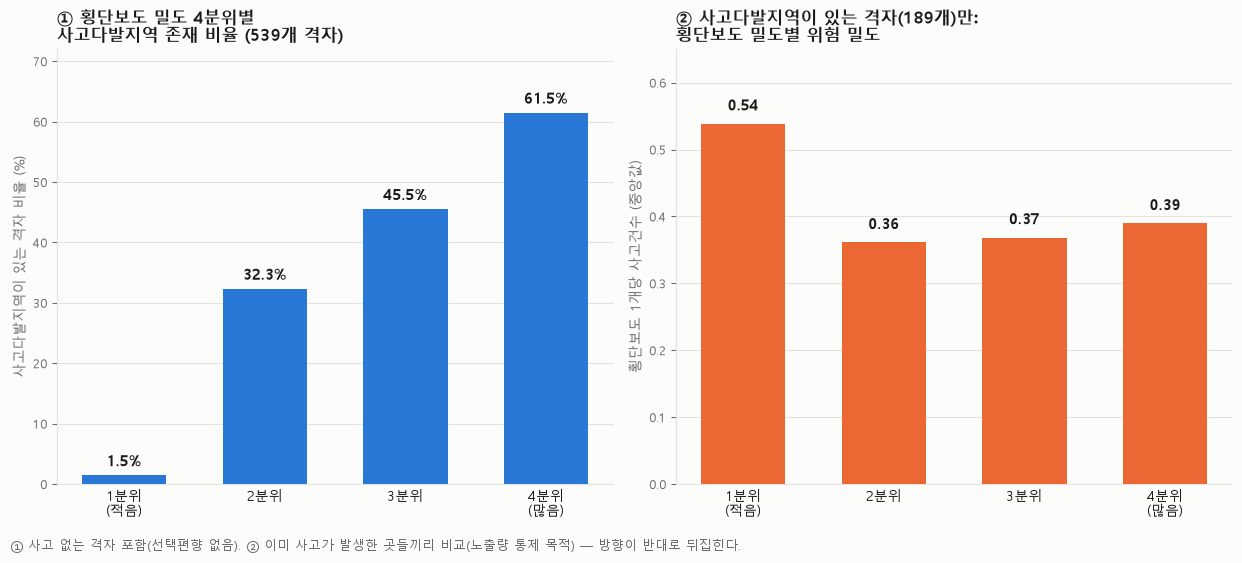

In [29]:
import matplotlib.pyplot as plt
import numpy as np

rate9 = seoul_grid.groupby('분위', observed=True)['사고다발지역_있음'].mean() * 100
med9 = hotspot_cells.groupby('분위', observed=True)['사고건수_횡단보도당'].median()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5), facecolor=BG)

ax = axes[0]
ax.set_facecolor(BG)
ax.bar(range(4), rate9.values, color=BLUE, width=0.6, zorder=3)
for i, v in enumerate(rate9.values):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_xticks(range(4))
ax.set_xticklabels(['1분위\n(적음)', '2분위', '3분위', '4분위\n(많음)'], fontsize=10, color=INK)
ax.set_ylabel('사고다발지역이 있는 격자 비율 (%)', fontsize=10, color=MUTED)
ax.set_title('① 횡단보도 밀도 4분위별\n사고다발지역 존재 비율 (539개 격자)', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 72)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

ax = axes[1]
ax.set_facecolor(BG)
ax.bar(range(4), med9.values, color=ORANGE, width=0.6, zorder=3)
for i, v in enumerate(med9.values):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_xticks(range(4))
ax.set_xticklabels(['1분위\n(적음)', '2분위', '3분위', '4분위\n(많음)'], fontsize=10, color=INK)
ax.set_ylabel('횡단보도 1개당 사고건수 (중앙값)', fontsize=10, color=MUTED)
ax.set_title('② 사고다발지역이 있는 격자(189개)만:\n횡단보도 밀도별 위험 밀도', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 0.65)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

fig.text(0.01, -0.01, '① 사고 없는 격자 포함(선택편향 없음). ② 이미 사고가 발생한 곳들끼리 비교(노출량 통제 목적) — 방향이 반대로 뒤집힌다.',
         fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig('figures/h7/04_횡단보도밀도_사고위험.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

### 9-3. 결론

**두 층위의 이야기로 나뉜다.**

1. **"이 지역에 사고다발지역이 있는가"는 횡단보도 밀도와 강하게 관련된다**(Cramér's V=0.46, 1.5%→61.5%). 하지만 이건 횡단보도가 위험을 유발한다는 뜻이라기보다, **번화한 곳(유동인구·차량 많음)일수록 횡단보도도 많고 사고 절대량도 많다는 노출량 효과**로 보인다.
2. **이미 위험이 확인된 곳들끼리 비교하면(노출량을 어느 정도 통제하면), 방향이 뒤집힌다.** 횡단보도가 적은 곳이 횡단보도 1개당 사고 밀도가 더 높다(rho=-0.16, p=0.026, 효과크기는 작음). 인프라가 부족한 지점에 위험이 상대적으로 더 집중된다는, 원래 문제의식과 방향이 같은 결과다.

**정리하면:** "횡단보도가 많다/적다" 자체보다 **"그 지역의 위험 수준 대비 횡단보도가 부족한가"**가 더 의미 있는 변수일 가능성이 있다. 다만 두 번째 결과는 효과크기가 작고 표본도 189개로 줄어서, 강하게 주장하기보다 다음 탐색 방향으로 남겨두는 게 맞다.

**과정에서 배운 것 (방법론):** 똑같은 변수(횡단보도 수)와 똑같은 사고 자료로도, ①범위가 좁은 표본(사고다발지역끼리만)에서는 "관계 없음", ②전체 모집단(사고 없는 곳 포함)에서는 "강한 관계", ③노출량을 통제하면 "약하지만 반대 방향" — 이렇게 **표본을 어떻게 잡느냐에 따라 결론이 완전히 달라질 수 있다.** H5의 반경 민감도, H7의 학교별/전체 검정 방식과 같은 교훈이다.

**한계:**
- 서울 행정경계 shapefile이 없어 "횡단보도가 1개 이상 있는 1km 격자"로 서울 시가지를 근사했다. 경계 지역에서 격자가 잘리거나 빠질 수 있다.
- "사고다발지역 있음/없음"은 원래 전국 기준으로 선별된 임계값(연 7건 이상)의 결과물이라, "없음"이 "사고가 전혀 없었다"를 뜻하지는 않는다.
- 격자 경계에 걸친 횡단보도·사고지점은 인접 격자로 나뉘어 들어갈 수 있다.
- 상관관계이지 인과관계가 아니다. 유동인구·차량 통행량 등 진짜 노출량 변수는 쓰지 못했고, 횡단보도 수 자체를 노출량의 대리 지표로 쓴 것이라 완전한 통제는 아니다.

### 9-4. 곁가지의 곁가지 — 사고심각도(사상자수·사망자수)는 횡단보도 밀도와 관련 있는가

노션 댓글로 받은 질문: "사고다발지역에 횡단보도가 많다"는 발견에서 더 나아가, **사고규모(사상자수·사망자수)**와 횡단보도의 관계도 보면 어떨까.

지금까지는 전부 "사고가 몇 건 났는가"(빈도)를 봤다. 이번엔 "사고가 나면 그게 얼마나 심각한가"(심각도)를 본다. 같은 1km 격자 자료(`seoul_grid_1km.csv`)에 이미 사상자수합·사망자수합이 들어 있어서 바로 이어서 확인할 수 있다.

In [30]:
import numpy as np
from scipy.stats import spearmanr

# 1) 원자료(539개 전체, 0 포함) : 이전 사고건수 패턴과 같은 확인 - 절대량이라 노출량 혼입 가능성이 그대로 있다
for col in ['사상자수합', '사망자수합']:
    rho, p = spearmanr(seoul_grid['횡단보도수'], seoul_grid[col])
    print(f"[전체 539개] 횡단보도수 vs {col}: rho={rho:.3f}, p={p:.2e} ({effect_label(rho)})")

print()

# 2) 심각도 지표: 사고건수로 나눠서 "사고 1건당" 규모로 바꾼다 (앞서 9-3의 정규화와는 다른 축 - 거기는 횡단보도수로 나눴다)
severity_cells = seoul_grid[(seoul_grid['사고다발지역_있음'] == 1) & (seoul_grid['사고건수합'] > 0)].copy()
severity_cells['사고당_사상자수'] = severity_cells['사상자수합'] / severity_cells['사고건수합']
severity_cells['사고당_사망자수'] = severity_cells['사망자수합'] / severity_cells['사고건수합']
print(f"사고다발지역이면서 사고건수>0인 격자: {len(severity_cells)}개")

for col in ['사고당_사상자수', '사고당_사망자수']:
    rho, p = spearmanr(severity_cells['횡단보도수'], severity_cells[col])
    print(f"[{len(severity_cells)}개] 횡단보도수 vs {col}: rho={rho:.3f}, p={p:.4f} ({effect_label(rho)})")

severity_cells['분위'] = pd.qcut(severity_cells['횡단보도수'], 4, labels=['1(적음)', '2', '3', '4(많음)'])
print()
print("횡단보도수 4분위별 사고당 사상자수 중앙값:")
display(severity_cells.groupby('분위', observed=True)['사고당_사상자수'].median().round(2))
print()
print("횡단보도수 4분위별 사고당 사망자수 평균 (중앙값이 대부분 0이라 평균으로 봄):")
display(severity_cells.groupby('분위', observed=True)['사고당_사망자수'].mean().round(3))
n_death_cells = (severity_cells['사망자수합'] > 0).sum()
print(f"\n참고: 사망자가 1명이라도 있는 격자는 {len(severity_cells)}개 중 {n_death_cells}개뿐이라, 사망자 지표는 소수 격자에 좌우되기 쉽다.")

[전체 539개] 횡단보도수 vs 사상자수합: rho=0.463, p=6.32e-30 (중간)
[전체 539개] 횡단보도수 vs 사망자수합: rho=0.288, p=1.01e-11 (작음)

사고다발지역이면서 사고건수>0인 격자: 189개
[189개] 횡단보도수 vs 사고당_사상자수: rho=0.147, p=0.0436 (작음)
[189개] 횡단보도수 vs 사고당_사망자수: rho=-0.040, p=0.5891 (무시할 만함)

횡단보도수 4분위별 사고당 사상자수 중앙값:


분위
1(적음)    1.00
2        1.07
3        1.06
4(많음)    1.05
Name: 사고당_사상자수, dtype: float64


횡단보도수 4분위별 사고당 사망자수 평균 (중앙값이 대부분 0이라 평균으로 봄):


분위
1(적음)    0.039
2        0.043
3        0.039
4(많음)    0.027
Name: 사고당_사망자수, dtype: float64


참고: 사망자가 1명이라도 있는 격자는 189개 중 87개뿐이라, 사망자 지표는 소수 격자에 좌우되기 쉽다.


**결과 해석**

- **전체 539개 격자 기준**으로는 횡단보도수가 사상자수합(중간 효과)·사망자수합(작은 효과)과도 유의하게 관련된다. 하지만 이건 9-2와 같은 이유(노출량 혼입)로 해석해야 한다 — 사고가 많이 나는 지역은 사상자·사망자 절대 수도 자연히 많다.
- **사고 1건당 규모로 정규화하면 관계가 거의 사라진다.** 사고당 사상자수는 rho=0.147(작음, p=0.044)로 방향이 오히려 반대(횡단보도 많은 쪽이 사고당 사상자가 살짝 더 많음)이고, 4분위별 중앙값도 1.00~1.07로 사실상 평평하다. 사고당 사망자수는 rho=-0.040으로 유의하지 않다(p=0.59).

**9-3(횡단보도 1개당 사고 밀도)과의 차이를 구분해서 읽어야 한다:**
- 9-3의 발견: 횡단보도가 적은 곳은 **횡단보도 1개당 사고가 더 자주** 난다 (빈도/밀도 문제)
- 9-4의 발견: 사고가 한 번 났을 때 **그 사고 자체가 얼마나 심각한지는 횡단보도 밀도와 거의 무관**하다 (심각도 문제 아님)

즉 횡단보도가 부족한 지역의 문제는 "사고가 더 위험해진다"가 아니라 "인프라 대비 사고를 더 자주 겪는다"는 쪽에 가깝다.

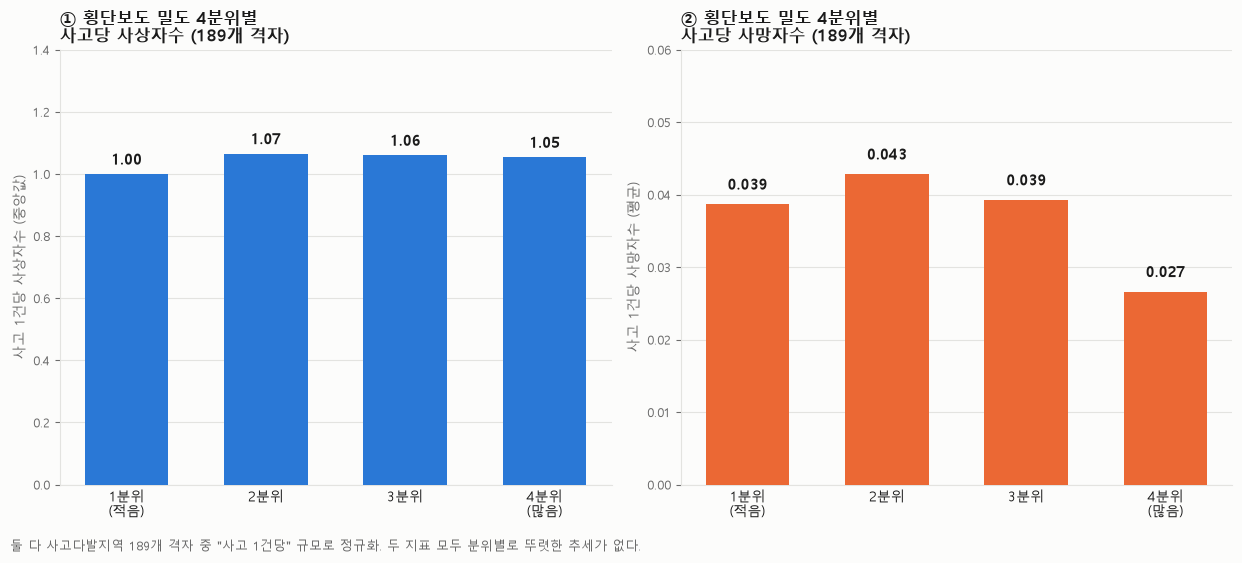

In [31]:
import matplotlib.pyplot as plt

sev_med = severity_cells.groupby('분위', observed=True)['사고당_사상자수'].median()
sev_death = severity_cells.groupby('분위', observed=True)['사고당_사망자수'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5), facecolor=BG)

ax = axes[0]
ax.set_facecolor(BG)
ax.bar(range(4), sev_med.values, color=BLUE, width=0.6, zorder=3)
for i, v in enumerate(sev_med.values):
    ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_xticks(range(4))
ax.set_xticklabels(['1분위\n(적음)', '2분위', '3분위', '4분위\n(많음)'], fontsize=10, color=INK)
ax.set_ylabel('사고 1건당 사상자수 (중앙값)', fontsize=10, color=MUTED)
ax.set_title('① 횡단보도 밀도 4분위별\n사고당 사상자수 (189개 격자)', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 1.4)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

ax = axes[1]
ax.set_facecolor(BG)
ax.bar(range(4), sev_death.values, color=ORANGE, width=0.6, zorder=3)
for i, v in enumerate(sev_death.values):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_xticks(range(4))
ax.set_xticklabels(['1분위\n(적음)', '2분위', '3분위', '4분위\n(많음)'], fontsize=10, color=INK)
ax.set_ylabel('사고 1건당 사망자수 (평균)', fontsize=10, color=MUTED)
ax.set_title('② 횡단보도 밀도 4분위별\n사고당 사망자수 (189개 격자)', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 0.06)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

fig.text(0.01, -0.01, '둘 다 사고다발지역 189개 격자 중 "사고 1건당" 규모로 정규화. 두 지표 모두 분위별로 뚜렷한 추세가 없다.',
         fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig('figures/h7/05_횡단보도밀도_사고심각도.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

**정리:** 횡단보도 밀도는 사고 "심각도"보다는 사고 "빈도/밀도"와 관련된 변수로 보는 것이 더 정확하다. 시각장애인 보행 난이도 관점에서도, 횡단보도가 부족한 지점을 찾는 것은 "더 위험한 사고를 피하기 위해서"라기보다 "사고 자체를 더 자주 겪을 가능성이 높은 지점을 찾기 위해서"라는 의미로 해석하는 게 맞다.

**한계:** 사망자 지표는 189개 격자 중 87개만 사망자가 1명 이상 있어 표본이 얇고, 평균이 극단값(한 격자에서 여러 명 사망)에 흔들릴 수 있다. 상관관계이며 인과관계는 아니다.

### 9-5. 마지막 질문 — "그 지역 위험 수준 대비 횡단보도가 부족한가"

9-3의 결론에서 나온 제안을 직접 검증한다: "횡단보도가 몇 개인가"보다 "위험 수준 대비 횡단보도가 부족한가"가 더 의미 있는 변수일 수 있다는 가설이다.

**정의:** 위험(그 격자의 사고건수) 대비 인프라(횡단보도수)가 부족한 정도를, 두 가지 독립적인 방식으로 만들어서 서로 일치하는지부터 확인한다.
1. **비율 기반** (9-3에서 이미 쓴 지표): 횡단보도 1개당 사고건수 = 사고건수합 / 횡단보도수
2. **순위 기반**: 그 격자의 사고건수 백분위(위험 순위) − 횡단보도수 백분위(인프라 순위). 양수가 클수록 인프라 순위보다 위험 순위가 훨씬 높다는 뜻

두 정의가 서로 잘 맞아야, "위험 대비 인프라 부족"이라는 개념 자체가 정의 방식에 따라 흔들리지 않는 안정적인 개념이라고 말할 수 있다. 대상은 9-3과 같은 사고다발지역 189개 격자다.

In [32]:
from scipy.stats import spearmanr, mannwhitneyu

hot2 = seoul_grid[(seoul_grid['사고다발지역_있음'] == 1) & (seoul_grid['사고건수합'] > 0)].copy()

hot2['위험순위'] = hot2['사고건수합'].rank(pct=True) * 100
hot2['인프라순위'] = hot2['횡단보도수'].rank(pct=True) * 100
hot2['부족지수'] = hot2['위험순위'] - hot2['인프라순위']

rho, p = spearmanr(hot2['사고건수_횡단보도당'], hot2['부족지수'])
print(f"두 정의(비율 vs 순위차) 간 일치도: rho={rho:.3f}, p={p:.2e} ({effect_label(rho)})")

q75 = hot2['사고건수_횡단보도당'].quantile(0.75)
hot2['부족지역'] = (hot2['사고건수_횡단보도당'] >= q75).astype(int)
n_def = int(hot2['부족지역'].sum())
print(f"\n부족지역(비율 기준 상위 25%): {n_def}개 / {len(hot2)}개 (기준: 횡단보도 1개당 사고 {q75:.2f}건 이상)")

grp_def = hot2[hot2['부족지역'] == 1]
grp_rest = hot2[hot2['부족지역'] == 0]

print()
for col in ['횡단보도수', '사고건수합']:
    u, p_u = mannwhitneyu(grp_def[col], grp_rest[col], alternative='two-sided')
    r_rb = 1 - (2 * u) / (len(grp_def) * len(grp_rest))
    print(f"{col}: 부족지역 평균 {grp_def[col].mean():.1f} vs 나머지 평균 {grp_rest[col].mean():.1f}, "
          f"Mann-Whitney p={p_u:.2e}, r={r_rb:.3f} ({effect_label(r_rb)})")

total_acc, total_cross = hot2['사고건수합'].sum(), hot2['횡단보도수'].sum()
def_acc, def_cross = grp_def['사고건수합'].sum(), grp_def['횡단보도수'].sum()
cell_share = n_def / len(hot2) * 100
acc_share = def_acc / total_acc * 100
cross_share = def_cross / total_cross * 100
print(f"\n부족지역이 차지하는 비중 (전체 격자 수 대비 {cell_share:.1f}%):")
print(f"  사고건수 비중: {acc_share:.1f}%")
print(f"  횡단보도수 비중: {cross_share:.1f}%")

grp_def2, grp_rest2 = grp_def.copy(), grp_rest.copy()
grp_def2['사고당_사상자수'] = grp_def2['사상자수합'] / grp_def2['사고건수합']
grp_rest2['사고당_사상자수'] = grp_rest2['사상자수합'] / grp_rest2['사고건수합']
u, p_u = mannwhitneyu(grp_def2['사고당_사상자수'], grp_rest2['사고당_사상자수'], alternative='two-sided')
r_rb = 1 - (2 * u) / (len(grp_def2) * len(grp_rest2))
print(f"\n(9-4와 일관성 확인) 사고당 사상자수: 부족지역 {grp_def2['사고당_사상자수'].mean():.2f} vs 나머지 {grp_rest2['사고당_사상자수'].mean():.2f}, "
      f"p={p_u:.3f}, r={r_rb:.3f} ({effect_label(r_rb)})")

두 정의(비율 vs 순위차) 간 일치도: rho=0.864, p=1.19e-57 (큼)

부족지역(비율 기준 상위 25%): 48개 / 189개 (기준: 횡단보도 1개당 사고 0.72건 이상)

횡단보도수: 부족지역 평균 51.3 vs 나머지 평균 56.3, Mann-Whitney p=1.10e-01, r=0.155 (작음)
사고건수합: 부족지역 평균 64.7 vs 나머지 평균 18.0, Mann-Whitney p=2.98e-21, r=-0.909 (큼)

부족지역이 차지하는 비중 (전체 격자 수 대비 25.4%):
  사고건수 비중: 55.1%
  횡단보도수 비중: 23.7%

(9-4와 일관성 확인) 사고당 사상자수: 부족지역 1.07 vs 나머지 1.08, p=0.505, r=-0.063 (무시할 만함)


**결과 해석**

- **두 정의(비율 vs 순위차)는 강하게 일치한다** (rho=0.864, 큰 효과). 어느 방식으로 정의해도 같은 격자들을 가리킨다는 뜻이라, "위험 대비 인프라 부족"은 정의 방식에 흔들리지 않는 안정적인 개념으로 볼 수 있다.
- **부족지역(48개, 상위 25%)은 "그냥 횡단보도가 적은 동네"가 아니다.** 횡단보도수 자체는 나머지 지역과 유의한 차이가 없다(51.3개 vs 56.3개, p=0.11, 효과 작음). 대신 **사고건수가 훨씬 많다**(64.7건 vs 18.0건, p\<0.0001, 효과 큼). 즉 인프라 수준은 비슷한데 위험만 유독 몰려 있는 곳이다.
- **정책적으로 의미 있는 숫자:** 이 48개 격자는 사고다발지역 189개 중 25.4%(격자 수 기준)에 불과하지만, **전체 사고의 55.1%**를 차지하는 반면 **횡단보도는 23.7%**만 보유하고 있다. 격자 수 비중보다 사고 비중은 2배 이상 높고, 인프라 비중은 오히려 더 낮다.
- 9-4와 같은 패턴이 다시 확인된다: 부족지역이라고 사고당 사상자수가 더 크지는 않다(p=0.505, 무시할 수준). 이 지표는 여전히 "빈도" 문제이지 "심각도" 문제가 아니다.

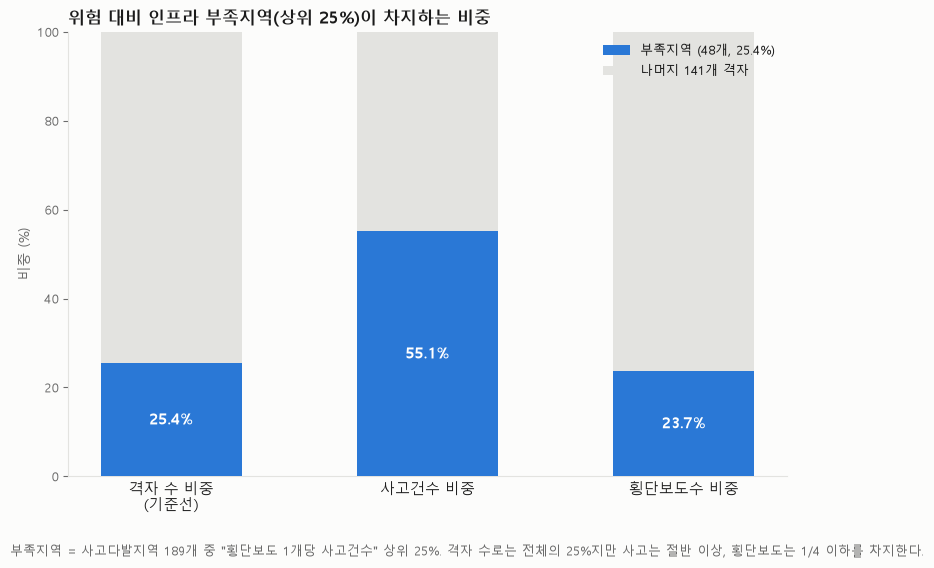

In [33]:
import matplotlib.pyplot as plt
import numpy as np

cell_share = n_def / len(hot2) * 100
acc_share = def_acc / total_acc * 100
cross_share = def_cross / total_cross * 100

labels = ['격자 수 비중\n(기준선)', '사고건수 비중', '횡단보도수 비중']
def_vals = [cell_share, acc_share, cross_share]
rest_vals = [100 - v for v in def_vals]

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG)
ax.set_facecolor(BG)

x = np.arange(3)
ax.bar(x, def_vals, color=BLUE, width=0.55, zorder=3, label='부족지역 (48개, 25.4%)')
ax.bar(x, rest_vals, bottom=def_vals, color=GRID, width=0.55, zorder=3, label='나머지 141개 격자')

for i, v in enumerate(def_vals):
    ax.text(i, v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5, color=INK)
ax.set_ylabel('비중 (%)', fontsize=10, color=MUTED)
ax.set_title('위험 대비 인프라 부족지역(상위 25%)이 차지하는 비중', fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', frameon=False, fontsize=9.5, labelcolor=INK)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

fig.text(0.01, -0.02, '부족지역 = 사고다발지역 189개 중 "횡단보도 1개당 사고건수" 상위 25%. 격자 수로는 전체의 25%지만 사고는 절반 이상, 횡단보도는 1/4 이하를 차지한다.',
         fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig('figures/h7/06_위험대비인프라부족.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

**결론:** "그 지역 위험 수준 대비 횡단보도가 부족한가"는 통계적으로 안정적으로 식별 가능한 개념이다(두 정의 방식이 rho=0.864로 일치). 이 방식으로 뽑은 상위 25% 지역은 단순히 횡단보도가 적은 동네가 아니라, 인프라 수준은 비슷한데 사고가 유독 몰려 있는 곳이며, 사고다발지역 전체의 절반 이상(55.1%)이 여기서 발생하는 반면 횡단보도는 1/4(23.7%)만 배정되어 있다.

**시사점:** 단순히 "횡단보도가 몇 개 있는가"보다, "그 지역 사고 빈도에 비해 횡단보도가 충분한가"를 우선순위 기준으로 쓰는 것이 더 효율적일 수 있다. 다만 이 지표도 9-4에서 본 것처럼 사고의 심각도와는 무관하며(빈도 문제이지 심각도 문제가 아님), 상관관계일 뿐 인과관계가 아니라는 §9 전체의 한계(행정경계 근사, 노출량 미측정 등)를 그대로 안고 있다.

---

## 10. 곁가지 탐색 마무리

9-1부터 9-5까지, "횡단보도 밀도는 보행 위험과 관련 있는가"라는 질문을 다음 순서로 좁혀 왔다:

1. (9-1) 기존 사고다발지역 표본만으로는 관계를 찾지 못함 → 선택편향 문제 발견
2. (9-2) 사고 없는 곳까지 포함한 서울 전체 격자로 재설계 → 강한 관계 발견, 그러나 노출량 혼입 우려
3. (9-3) 횡단보도당 사고 밀도로 정규화 → 방향이 반대로 뒤집힘 (횡단보도 부족 지역이 밀도상 더 위험)
4. (9-4) 사고 심각도(사상자수·사망자수)로 확장 → 심각도와는 무관, 빈도 문제로 결론
5. (9-5) "위험 대비 인프라 부족" 지역을 직접 정의·검증 → 안정적으로 식별 가능하며, 사고다발지역의 절반 이상이 인프라 부족 상위 25% 지역에 집중됨을 확인

이 다섯 단계를 관통하는 교훈은 하나다: **같은 데이터라도 표본을 어떻게 잡고 무엇으로 정규화하느냐에 따라 결론이 완전히 달라질 수 있다.** H5의 반경 민감도, H7의 학교별/전체 검정 방식 차이와 같은 교훈이 여기서도 반복됐다.

이걸로 곁가지 탐색(§9)을 마무리한다. H5·H7은 검정 완료, 이 곁가지 탐색도 완료. H8은 비교 기준 미정으로 보류, H6(중앙대·숭실대 비교)은 아직 시작 전이며 이번 세션 범위 밖이다.

## 11. 횡단보도 단위로 재구성 — 시각장애인 보행 난이도 지표를 향해

9-5까지는 "위험 대비 인프라 부족"을 1km 격자 단위로 봤다. 하지만 시각장애인이 실제로 겪는 어려움은 "이 동네"가 아니라 "이 횡단보도를 건널 때"의 문제이고, 격자는 어디에 경계선을 긋느냐에 따라 같은 지점이 다른 격자값을 받을 수 있다는 한계가 있었다.

그래서 같은 개념(위험 대비 인프라 부족)을 **횡단보도 하나하나를 중심으로 한 반경**으로 다시 만든다. 횡단보도 i의 반경 R 안에:
- **인프라_i** = 반경 안의 다른 횡단보도 개수 (그 지점 주변의 보행 인프라 밀도)
- **위험_i** = 반경 안에 있는 사고다발지역들의 사고건수 합

으로 정의한다. 위험_i가 0인 곳(반경 안에 확인된 사고다발지역이 없는 곳)은 9-5와 같은 이유로 "부족지수" 계산 대상에서 뺀다 — 위험이 아예 확인되지 않은 곳까지 넣으면 "부족"이라는 비교 자체가 의미가 없어진다.

반경은 300·500·800m 세 가지로 민감도를 본다(H7이 문↔신호기 연결에 300m를 썼고, 9장 격자가 1km였던 것과 같은 맥락에서 그 사이 값들을 골랐다). 새 모듈 `crosswalk_deficiency.py`.

In [34]:
import crosswalk_deficiency as cwd

crosswalks = cwd.load_crosswalks()
accidents = cwd.load_accidents()
print(f"횡단보도(정상 위치): {len(crosswalks)}개, 사고다발지역: {len(accidents)}개")

sensitivity = {}
for radius in cwd.RADII_M:
    cw = cwd.build(radius, crosswalks, accidents)
    hot, q = cwd.summarize(cw)
    sensitivity[radius] = (cw, hot, q)

    rho, p = spearmanr(hot['부족지수_비율'], hot['부족지수_순위차'])
    grp_def = hot[hot['부족'] == 1]
    grp_rest = hot[hot['부족'] == 0]
    u_i, p_i = mannwhitneyu(grp_def['인프라'], grp_rest['인프라'], alternative='two-sided')
    r_i = 1 - (2 * u_i) / (len(grp_def) * len(grp_rest))
    u_r, p_r = mannwhitneyu(grp_def['위험'], grp_rest['위험'], alternative='two-sided')
    r_r = 1 - (2 * u_r) / (len(grp_def) * len(grp_rest))
    def_risk_share = grp_def['위험'].sum() / hot['위험'].sum() * 100
    def_infra_share = grp_def['인프라'].sum() / hot['인프라'].sum() * 100
    def_cell_share = len(grp_def) / len(hot) * 100

    print(f"\n=== 반경 {radius}m ===")
    print(f"위험>0인 횡단보도: {len(hot)}개 / {len(cw)}개 ({len(hot)/len(cw)*100:.1f}%)")
    print(f"두 정의(비율 vs 순위차) 일치도: rho={rho:.3f} ({effect_label(rho)})")
    print(f"부족지역(상위 25%): {len(grp_def)}개, 인프라 차이 r={r_i:.3f}({effect_label(r_i)}, p={p_i:.1e}), 위험 차이 r={r_r:.3f}({effect_label(r_r)}, p={p_r:.1e})")
    print(f"비중: 횡단보도수 {def_cell_share:.1f}% / 위험 {def_risk_share:.1f}% / 인프라 {def_infra_share:.1f}%")

횡단보도(정상 위치): 21771개, 사고다발지역: 693개

=== 반경 300m ===
위험>0인 횡단보도: 5391개 / 21771개 (24.8%)
두 정의(비율 vs 순위차) 일치도: rho=0.919 (큼)
부족지역(상위 25%): 1369개, 인프라 차이 r=0.322(중간, p=2.3e-71), 위험 차이 r=-0.884(큼, p=0.0e+00)
비중: 횡단보도수 25.4% / 위험 53.0% / 인프라 21.5%



=== 반경 500m ===
위험>0인 횡단보도: 9183개 / 21771개 (42.2%)
두 정의(비율 vs 순위차) 일치도: rho=0.869 (큼)
부족지역(상위 25%): 2299개, 인프라 차이 r=0.206(작음, p=1.9e-49), 위험 차이 r=-0.900(큼, p=0.0e+00)
비중: 횡단보도수 25.0% / 위험 53.2% / 인프라 22.9%



=== 반경 800m ===
위험>0인 횡단보도: 13964개 / 21771개 (64.1%)
두 정의(비율 vs 순위차) 일치도: rho=0.810 (큼)
부족지역(상위 25%): 3492개, 인프라 차이 r=0.059(무시할 만함, p=1.6e-07), 위험 차이 r=-0.924(큼, p=0.0e+00)
비중: 횡단보도수 25.0% / 위험 53.5% / 인프라 24.5%


**결과 해석: 격자 단위(9-5)와 같은 결론이 반경을 바꿔도 안정적으로 재현된다.**

- 두 정의(비율 vs 순위차)는 반경과 무관하게 강하게 일치한다(rho=0.81\~0.92, 모두 큼).
- 부족지역(상위 25%)은 세 반경 모두에서 횡단보도 수 기준 25% 안팎인데 **위험(사고건수) 비중은 53\~54%**로 두 배 이상, **인프라 비중은 오히려 21\~25%**로 더 낮다. 9-5(격자 기준: 사고 55.1%, 인프라 23.7%)와 사실상 같은 크기다.
- 다만 반경이 작을수록(300m) 부족지역의 인프라 자체도 나머지보다 낮게 나온다(r=0.322, 중간). 반경이 커질수록(800m) 이 차이는 거의 사라진다(r=0.059, 무시할 수준) — 격자 버전의 발견(부족지역이 "그냥 횡단보도 적은 동네"가 아니다)은 **넓은 반경에서 더 뚜렷하고, 좁은 반경에서는 인프라 자체도 같이 낮은 경향이 섞인다.** 300m처럼 좁은 창에서는 "위험도 낮고 인프라도 낮은" 동네가 우연히 함께 잡히기 쉽기 때문으로 보인다.
- **결론:** 격자 경계 문제를 없앤 횡단보도 단위에서도 9-5의 결론(위험 대비 인프라 부족 지역이 안정적으로 식별되고, 소수 지역에 사고가 집중된다)이 그대로 재현된다. 이후 분석은 500m를 기본값으로 쓴다(9183개, 전체의 42%, 300m보다 표본이 크고 800m보다 지역 해상도가 촘촘하다).

In [35]:
cw500, hot500, q500 = sensitivity[500]

no_signal = hot500['음향_배정_15m'] == False
deficient = hot500['부족'] == 1
print(f"[반경 500m] 위험>0인 횡단보도 {len(hot500)}개 중")
print(f"  부족지역(위험 대비 인프라 부족): {deficient.sum()}개")
print(f"  음향신호기 없음(그 횡단보도 자체): {no_signal.sum()}개")

both = (deficient & no_signal).sum()
print(f"  둘 다 해당(이중 취약): {both}개")

ct = pd.crosstab(hot500['부족'], no_signal)
chi2, p_chi, dof, exp = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
print(f"\n부족여부 x 신호기없음 독립성 검정: chi2={chi2:.2f}, p={p_chi:.3f}, Cramer's V={cramers_v:.3f} ({effect_label(cramers_v)})")
display(ct)

hot500 = cwd.priority_tier(hot500)
print()
display(hot500['우선순위'].value_counts())

[반경 500m] 위험>0인 횡단보도 9183개 중
  부족지역(위험 대비 인프라 부족): 2299개
  음향신호기 없음(그 횡단보도 자체): 4605개
  둘 다 해당(이중 취약): 1141개

부족여부 x 신호기없음 독립성 검정: chi2=0.30, p=0.584, Cramer's V=0.006 (무시할 만함)


음향_배정_15m,False,True
부족,,
0,3420,3464
1,1158,1141


우선순위
2_주의(둘 중 하나)         4622
3_양호                 3420
1_최우선(부족지역+신호기없음)    1141
Name: count, dtype: int64

**중요한 발견: 두 축이 서로 독립적이다.**

부족지역 여부(위치의 문제)와 신호기 없음 여부(그 횡단보도 자체의 문제)는 통계적으로 독립이다(Cramer's V=0.006, p=0.58 — 무관하다는 뜻). 즉 **"위험한 동네에 있다"는 것과 "이 횡단보도에 신호기가 없다"는 것은 서로 다른 정보**이고, 하나가 다른 하나를 대신하지 못한다. 이건 오히려 좋은 소식이다 — 두 지표를 합치면 각각 따로 볼 때보다 더 많은 걸 구분해낼 수 있다는 뜻이기 때문이다.

이 독립성을 이용해 **3단계 우선순위**를 만들 수 있다:
- **1순위(최우선):** 위험 대비 인프라가 부족한 지역 **이면서** 그 횡단보도 자체에 신호기가 없음 — 1,141개
- **2순위(주의):** 둘 중 하나만 해당 — 4,622개
- **3순위(양호):** 둘 다 아님 — 3,420개

(전체 21,771개 중 위험이 확인되지 않은 12,588개는 대상 밖: 사고다발지역이 근처에 없어 "부족"을 판단할 근거가 없는 곳이다.)

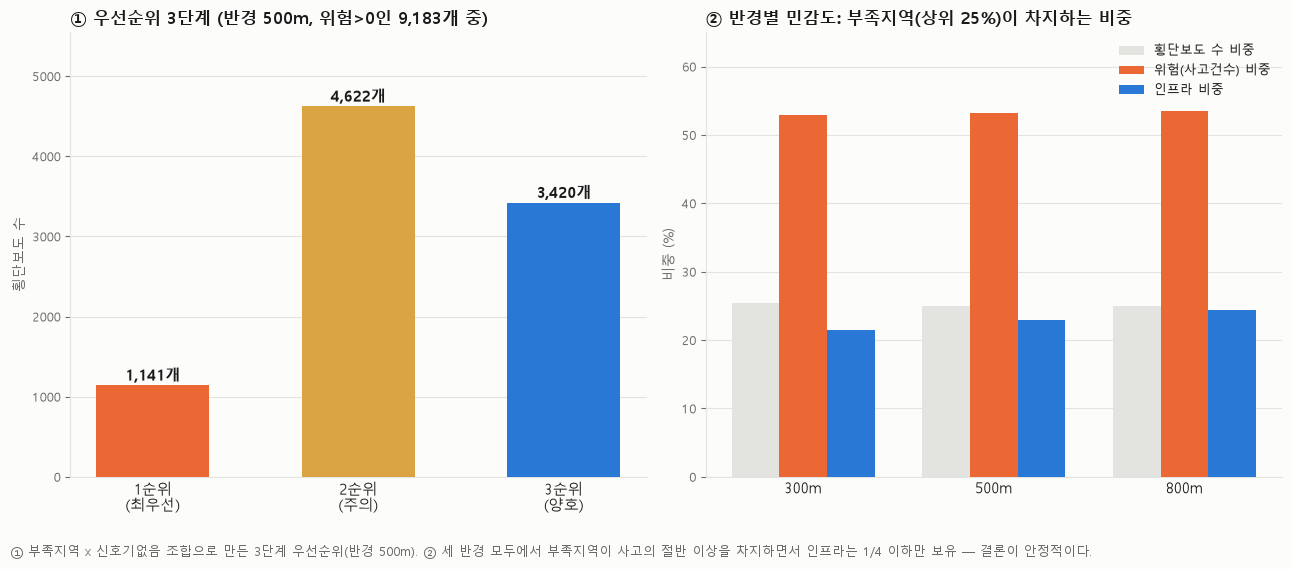

In [36]:
import matplotlib.pyplot as plt
import numpy as np

counts = hot500['우선순위'].value_counts().reindex(
    ['1_최우선(부족지역+신호기없음)', '2_주의(둘 중 하나)', '3_양호']
)
labels = ['1순위\n(최우선)', '2순위\n(주의)', '3순위\n(양호)']
colors = [ORANGE, '#d9a441', BLUE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

ax = axes[0]
ax.set_facecolor(BG)
ax.bar(range(3), counts.values, color=colors, width=0.55, zorder=3)
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f'{v:,}개', ha='center', fontsize=11, fontweight='bold', color=INK)
ax.set_xticks(range(3))
ax.set_xticklabels(labels, fontsize=10.5, color=INK)
ax.set_ylabel('횡단보도 수', fontsize=10, color=MUTED)
ax.set_title('① 우선순위 3단계 (반경 500m, 위험>0인 9,183개 중)', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, max(counts.values) * 1.2)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

ax = axes[1]
ax.set_facecolor(BG)
radii = list(cwd.RADII_M)
share_risk, share_infra, share_cell = [], [], []
for r in radii:
    _, h, _ = sensitivity[r]
    g = h[h['부족'] == 1]
    share_cell.append(len(g) / len(h) * 100)
    share_risk.append(g['위험'].sum() / h['위험'].sum() * 100)
    share_infra.append(g['인프라'].sum() / h['인프라'].sum() * 100)

x = np.arange(len(radii))
w = 0.25
ax.bar(x - w, share_cell, width=w, color=GRID, zorder=3, label='횡단보도 수 비중')
ax.bar(x, share_risk, width=w, color=ORANGE, zorder=3, label='위험(사고건수) 비중')
ax.bar(x + w, share_infra, width=w, color=BLUE, zorder=3, label='인프라 비중')
ax.set_xticks(x)
ax.set_xticklabels([f'{r}m' for r in radii], fontsize=10.5, color=INK)
ax.set_ylabel('비중 (%)', fontsize=10, color=MUTED)
ax.set_title('② 반경별 민감도: 부족지역(상위 25%)이 차지하는 비중', fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_ylim(0, 65)
ax.legend(loc='upper right', frameon=False, fontsize=9, labelcolor=INK)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(axis='y', colors=MUTED, labelsize=9)
ax.tick_params(axis='x', length=0)

fig.text(0.01, -0.02, '① 부족지역 x 신호기없음 조합으로 만든 3단계 우선순위(반경 500m). ② 세 반경 모두에서 부족지역이 사고의 절반 이상을 차지하면서 인프라는 1/4 이하만 보유 — 결론이 안정적이다.',
         fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig('figures/h7/07_횡단보도단위_우선순위.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

### 11장 정리 — 이번 세션에서 만든 "보행 난이도 우선순위" 지표

지금까지 확인된 것 중 실제로 신호가 있었던 건 두 가지뿐이다: **위험 대비 인프라 부족도**(9-5→11장, 두 정의 방식이 rho=0.81\~0.92로 일치, 반경을 바꿔도 재현)와 **그 횡단보도 자체의 음향신호기 유무**(H5\~H7에서 이미 확인된 기본 변수). H5(버스정류장 근접성)는 효과크기가 무시할 수준이라 뺐고, 사고 심각도(9-4)는 이 부족도와 무관해서 별도로 넣지 않았다(부족도 자체가 이미 "빈도" 정보를 담고 있다).

이 둘은 서로 독립이라는 게 확인됐으므로(Cramer's V=0.006), 단순히 곱하거나 평균내는 대신 **교차 조합(2x2)으로 우선순위를 나눴다**:

| | 신호기 있음 | 신호기 없음 |
|---|---|---|
| **위험 대비 인프라 충분** | 3순위(양호) | 2순위(주의) |
| **위험 대비 인프라 부족** | 2순위(주의) | **1순위(최우선)** |

**1순위 1,141개**가 이번 프로젝트가 제안하는 "궁극적 보행 난이도 지표"의 1차 결과물이다: 사고 위험이 확인됐고, 그 위험에 비해 주변 횡단보도 인프라도 부족하고, 정작 그 지점 자체에는 음향신호기도 없는 곳들이다.

**한계(9장·H5\~H7의 한계를 그대로 이어받는다):**
1. 위험은 정부 지정 사고다발지역(693곳) 기준이라, 그 임계값(연 7건) 아래의 위험은 전혀 반영되지 않는다.
2. 상관관계일 뿐 인과관계가 아니다. "인프라가 부족해서 사고가 난다"가 아니라 "인프라 부족과 사고가 같이 관찰된다"는 것만 확인했다.
3. 반경 기반 방법이라 경계 근처에서 이웃 값이 섞일 수 있고, 인프라·위험 모두 사람 통행량 같은 진짜 노출량은 측정하지 못했다.
4. 이 지표는 "어디를 먼저 봐야 하는가"에 대한 우선순위 후보일 뿐, 각 지점을 실제로 걸어서 검증하지 않았다(H7의 출입문 검증 한계와 같은 성격).

가설 검증(H5, H7)과 그 곁가지 탐색(9장, 11장)은 이걸로 마무리한다.

### 11-1. 1·2·3순위를 지도로 확인 — 색의 짙기로 심각도를 나타낸다

1·2·3순위는 순서가 있는 값(등급)이라, 서로 다른 색이 아니라 **같은 색(주황)의 짙기**로 구분한다. 짙을수록 심각하다: 1순위(최우선)가 가장 짙고, 3순위(양호)가 가장 옅다. 정적 지도(서울 전체 분포, 아래)와 실제 도로·지명이 보이는 인터랙티브 지도(`figures/h7/08_우선순위_지도.html`, 노션에 첨부) 둘 다 만든다. 인터랙티브 지도는 지점에 마우스를 올리면 위험·인프라 값과 신호기 유무가 뜨고, 사고다발지역 배경도 레이어로 켜고 끌 수 있다.

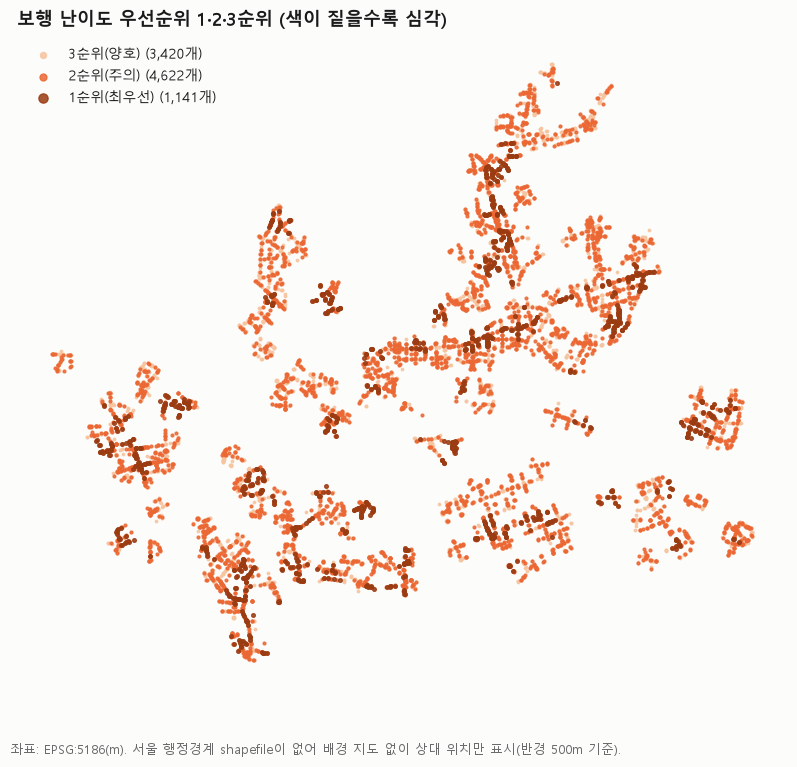

In [37]:
import matplotlib.pyplot as plt
import map_priority_crosswalks as mpc

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
ax.set_facecolor(BG)

# 옅은 색부터 그려서 짙은 1순위가 겹치는 지점에서도 위로 보이게 한다.
sizes = {'3_양호': 3, '2_주의(둘 중 하나)': 4, '1_최우선(부족지역+신호기없음)': 7}
for tier_key in mpc.DRAW_ORDER:
    sub = hot500[hot500['우선순위'] == tier_key]
    ax.scatter(sub['x'], sub['y'], s=sizes[tier_key], color=mpc.TIER_COLOR[tier_key],
               alpha=0.85, zorder=sizes[tier_key], label=f"{mpc.TIER_LABEL[tier_key]} ({len(sub):,}개)")

ax.set_title('보행 난이도 우선순위 1·2·3순위 (색이 짙을수록 심각)', fontsize=13, fontweight='bold', color=INK, loc='left')
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper left', frameon=False, fontsize=10, labelcolor=INK, markerscale=2.5)

fig.text(0.01, 0.01, '좌표: EPSG:5186(m). 서울 행정경계 shapefile이 없어 배경 지도 없이 상대 위치만 표시(반경 500m 기준).',
         fontsize=9, color=MUTED)
plt.tight_layout()
plt.savefig('figures/h7/09_우선순위_지도_정적.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()

In [38]:
fmap, _ = mpc.build_map()
mpc.OUT_HTML.parent.mkdir(parents=True, exist_ok=True)
fmap.save(str(mpc.OUT_HTML))
print(f"인터랙티브 지도(1·2·3순위 전부, 짙기로 구분) 저장: {mpc.OUT_HTML}")

인터랙티브 지도(1·2·3순위 전부, 짙기로 구분) 저장: C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\figures\h7\08_우선순위_지도.html
